In [1]:
import numpy as np
import torch
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import pandas as pd
import os
import re
import polars as pl
from collections import defaultdict
import matplotlib.gridspec as gridspec

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
mc_path = "/home/aegis/Titan1/NRAD/data/Regions_MC"
data_path = "/home/aegis/Titan1/NRAD/data/Regions_data_ver2"

mc_processes = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]

raw_weights = ["raw_weights", "weight_ngen", "weight_sub_weight", "weight_tot_weight"]
SCALAR_VARS = ["met_recalc_pt", "met_recalc_phi"]
VECTOR_VARS = [
    "AnalysisJetsAuxDyn_pt", "AnalysisJetsAuxDyn_eta", "AnalysisJetsAuxDyn_phi", 
    "AnalysisLargeRJetsAuxDyn_pt", "AnalysisLargeRJetsAuxDyn_eta", "AnalysisLargeRJetsAuxDyn_phi",
    "AnalysisLargeRJetsAuxDyn_Tau1_wta", "AnalysisLargeRJetsAuxDyn_Tau2_wta", "AnalysisLargeRJetsAuxDyn_Tau3_wta"
]

columns_to_load_mc = raw_weights + SCALAR_VARS + VECTOR_VARS
columns_to_load_data = SCALAR_VARS + VECTOR_VARS

### Check MC Distributions

In [3]:
MC_CR1L_paths = glob.glob(os.path.join(mc_path, "CR_1L", "*.parquet"))
MC_CR1L1B_paths = glob.glob(os.path.join(mc_path, "CR_1L1B", "*.parquet"))
MC_CR2L_paths = glob.glob(os.path.join(mc_path, "CR_2L", "*.parquet"))
MC_CR0L_paths = glob.glob(os.path.join(mc_path, "CR_MJRR", "*.parquet"))
MC_SR_paths = glob.glob(os.path.join(mc_path, "SR", "*.parquet"))

print("W+jets dominated background (CR1L) files", len(MC_CR1L_paths))
print("Top dominated background (CR1L1B) files", len(MC_CR1L1B_paths))
print("Z+jets dominated background (CR2L) files", len(MC_CR2L_paths))
print("Multijet dominated background (CR0L) files", len(MC_CR0L_paths))
print("Signal region (SR) files", len(MC_SR_paths))

print()
print("="*50)
print()

DATA_CR1L_paths = glob.glob(os.path.join(data_path, "CR_1L", "*.parquet"))
DATA_CR1L1B_paths = glob.glob(os.path.join(data_path, "CR_1L1B", "*.parquet"))
DATA_CR2L_paths = glob.glob(os.path.join(data_path, "CR_2L", "*.parquet"))
DATA_CR0L_paths = glob.glob(os.path.join(data_path, "CR_MJRR", "*.parquet"))
DATA_SR_paths = glob.glob(os.path.join(data_path, "SR", "*.parquet"))

print("W+jets dominated background (CR1L) data files", len(DATA_CR1L_paths))
print("Top dominated background (CR1L1B) data files", len(DATA_CR1L1B_paths))
print("Z+jets dominated background (CR2L) data files", len(DATA_CR2L_paths))
print("Multijet dominated background (CR0L) data files", len(DATA_CR0L_paths))
print("Signal region (SR) data files", len(DATA_SR_paths))

W+jets dominated background (CR1L) files 2894
Top dominated background (CR1L1B) files 2610
Z+jets dominated background (CR2L) files 2074
Multijet dominated background (CR0L) files 3062
Signal region (SR) files 3152


W+jets dominated background (CR1L) data files 36126
Top dominated background (CR1L1B) data files 36122
Z+jets dominated background (CR2L) data files 23188
Multijet dominated background (CR0L) data files 36465
Signal region (SR) data files 36467


In [4]:
def calc_features(lf: pl.LazyFrame, is_MC) -> pl.LazyFrame:
    """
    Calculates only HT, Mjj, and tau ratios, then discards all low-level vectors.
    """
    # 1. Extract the specific elements we need from the arrays
    lf = lf.with_columns(
        # HT: Scalar sum of all jet pt
        # ht = pl.col("AnalysisJetsAuxDyn_pt").list.sum() / 1000.0,
        
        ht = (
            pl.col("AnalysisJetsAuxDyn_pt")
            .list.gather(
                pl.col("AnalysisJetsAuxDyn_eta").list.eval(
                    (pl.element().abs() < 2.8).arg_true()
                )
            )
            .list.sum() / 1000.0
        ),
        # Leading and Subleading Jet Kinematics for Mjj
        j1_pt = pl.col("AnalysisJetsAuxDyn_pt").list.get(0),
        j2_pt = pl.col("AnalysisJetsAuxDyn_pt").list.get(1),
        j1_eta = pl.col("AnalysisJetsAuxDyn_eta").list.get(0),
        j2_eta = pl.col("AnalysisJetsAuxDyn_eta").list.get(1),
        j1_phi = pl.col("AnalysisJetsAuxDyn_phi").list.get(0),
        j2_phi = pl.col("AnalysisJetsAuxDyn_phi").list.get(1),
        
        # Large-R Jet Taus (Index 0 is Lead, Index 1 is Sublead)
        lrj1_t1 = pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.get(0),
        lrj1_t2 = pl.col("AnalysisLargeRJetsAuxDyn_Tau2_wta").list.get(0),
        lrj1_t3 = pl.col("AnalysisLargeRJetsAuxDyn_Tau3_wta").list.get(0),
        lrj2_t1 = pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.get(1),
        lrj2_t2 = pl.col("AnalysisLargeRJetsAuxDyn_Tau2_wta").list.get(1),
        lrj2_t3 = pl.col("AnalysisLargeRJetsAuxDyn_Tau3_wta").list.get(1),
    )

    # 2. Calculate the final complex math
    lf = lf.with_columns(
        # Mjj formula
        mjj = (
            2 * pl.col("j1_pt") * pl.col("j2_pt") * ((pl.col("j1_eta") - pl.col("j2_eta")).cosh() - (pl.col("j1_phi") - pl.col("j2_phi")).cos())
        ).sqrt() / 1000.0,
        
        # Subjettiness ratios (with safe division)
        ljet1_tau21 = pl.when(pl.col("lrj1_t1") > 0).then(pl.col("lrj1_t2") / pl.col("lrj1_t1")).otherwise(0),
        ljet1_tau32 = pl.when(pl.col("lrj1_t2") > 0).then(pl.col("lrj1_t3") / pl.col("lrj1_t2")).otherwise(0),
        ljet2_tau21 = pl.when(pl.col("lrj2_t1") > 0).then(pl.col("lrj2_t2") / pl.col("lrj2_t1")).otherwise(0),
        ljet2_tau32 = pl.when(pl.col("lrj2_t2") > 0).then(pl.col("lrj2_t3") / pl.col("lrj2_t2")).otherwise(0),
    )

    # 3. KEEP ONLY WHAT YOU ASKED FOR. Everything else is flushed from memory.
    if is_MC:
        final_columns = [
            "mc_process", "subprocess",                                              # Labels
            "raw_weights", "weight_ngen", "weight_sub_weight", "weight_tot_weight",  # Weights
            "met_recalc_pt", "met_recalc_phi",                                       # MET
            "ht", "mjj",                                                             # Global Kinematics
            "ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"               # Subjettiness
        ]
    else:
        final_columns = [                                                            # Labels
            "met_recalc_pt", "met_recalc_phi",                                       # MET
            "ht", "mjj",                                                             # Global Kinematics
            "ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"               # Subjettiness
        ]
    return lf.select(final_columns)

def get_lazyframes(paths, is_mc):
    # Move this OUTSIDE the loop so it doesn't overwrite on every iteration
    files_by_meta = defaultdict(list)
    known_processes = ['Wjets', 'Zjets', 'ttbar', 'Diboson', 'Multijet', 'Single_top']
    
    for filepath in paths:
        filename = os.path.basename(filepath)
        
        if is_mc:
            # Identify the main mc_process
            mc_process = next((p for p in known_processes if filename.startswith(p)), "Other")
            
            # Clean the filename to extract just the subprocess
            name_no_ext = filename.replace(".parquet", "")
            
            if name_no_ext.startswith(mc_process + "_"):
                remainder = name_no_ext[len(mc_process) + 1:]
            else:
                remainder = name_no_ext
                
            # STRIP THE BATCH: This removes "_batch1762" from the end of the string
            subprocess = re.sub(r"_batch\d+$", "", remainder) 
            
            # Group all batches of the same subprocess together
            files_by_meta[(mc_process, subprocess)].append(filepath)
        else:
            # If it's real data, bypass the naming logic and group them all together
            # print(filepath)
            files_by_meta[("Data", "Data")].append(filepath)

    # Load the data into the DataFrame list
    lazy_frames = []

    # group_paths now contains ALL batch files for this specific key
    for (mc_process, subprocess), group_paths in files_by_meta.items():
        if is_mc:
            lf = pl.scan_parquet(group_paths).select(columns_to_load_mc)
            # Tag them with the clean labels only if it's Monte Carlo
            lf = lf.with_columns(
                pl.lit(mc_process).alias("mc_process"),
                pl.lit(subprocess).alias("subprocess")
            )
        else:
            lf = pl.scan_parquet(group_paths).select(columns_to_load_data)
            
        lf = calc_features(lf, is_mc)
        lazy_frames.append(lf)

    return lazy_frames

#### Process CR1L 
W+jets dominated background

In [5]:
MC_CR1L_lazy = get_lazyframes(MC_CR1L_paths, is_mc=True)
DATA_CR1L_lazy = get_lazyframes(DATA_CR1L_paths, is_mc=False)
# Execute the read and combine everything
MC_CR1L = pl.concat(MC_CR1L_lazy).collect()
DATA_CR1L = pl.concat(DATA_CR1L_lazy).collect()


#### Process CR1L1B
Top Dominated Background

In [6]:
MC_CR1L1B_lazy = get_lazyframes(MC_CR1L1B_paths, is_mc=True)
DATA_CR1L1B_lazy = get_lazyframes(DATA_CR1L1B_paths, is_mc=False)
# Execute the read and combine everything
MC_CR1L1B = pl.concat(MC_CR1L1B_lazy).collect()
DATA_CR1L1B = pl.concat(DATA_CR1L1B_lazy).collect()

#### Process CR2L
Z+jets dominated background

In [7]:
MC_CR2L_lazy = get_lazyframes(MC_CR2L_paths, is_mc=True)
DATA_CR2L_lazy = get_lazyframes(DATA_CR2L_paths, is_mc=False)
# Execute the read and combine everything
MC_CR2L = pl.concat(MC_CR2L_lazy).collect()
DATA_CR2L = pl.concat(DATA_CR2L_lazy).collect()

#### Process CR0L
Multijet dominated background

In [8]:
MC_CR0L_lazy = get_lazyframes(MC_CR0L_paths, is_mc=True)
DATA_CR0L_lazy = get_lazyframes(DATA_CR0L_paths, is_mc=False)
MC_CR0L = pl.concat(MC_CR0L_lazy).collect()
DATA_CR0L = pl.concat(DATA_CR0L_lazy).collect()

#### Process SR
The Signal Region

In [9]:
MC_SR_lazy = get_lazyframes(MC_SR_paths, is_mc=True)
DATA_SR_lazy = get_lazyframes(DATA_SR_paths, is_mc=False)
MC_SR = pl.concat(MC_SR_lazy).collect()
DATA_SR = pl.concat(DATA_SR_lazy).collect()

In [10]:
# 1. Load the official metadata from the CSV
meta_df = pl.read_csv("metadata.csv").select([
    "physics_short", 
    "crossSection_pb", 
    "genFiltEff", 
    "kFactor",
    "sumOfWeights"
]).rename({"physics_short": "subprocess"})

def plot_mc_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame, region_name: str = ""):
    """
    Plots Data vs MC using native ATLAS scale factor calculations.
    """
    
    # --- 1. THE NATIVE SCALE FACTOR CALCULATION ---
    # Join the metadata to the MC dataframe
    df_mc = df_mc.join(meta_df, on="subprocess", how="left")
    
    # Fill any missing efficiencies with 1.0
    df_mc = df_mc.with_columns([
        pl.col("genFiltEff").fill_null(1.0),
        pl.col("kFactor").fill_null(1.0),
        pl.col("sumOfWeights").fill_null(1.0)
    ])
    
    # The exact target luminosity you calculated
    LUMI = 25.289004522843967
    
    df_mc = df_mc.with_columns(
        official_scale_factor = (
            pl.col("crossSection_pb") * LUMI * 1000 * pl.col("genFiltEff") * pl.col("kFactor")
        ) / pl.col("raw_weights").sum()
    )
    
    # Multiply the raw generator weight by the official scale factor
    df_mc = df_mc.with_columns(
        final_weight =  pl.col("official_scale_factor")*pl.col("raw_weights")
    )
    
    # ==========================================================
    # INSERT THE EMPIRICAL NORMALIZATION HERE
    # ==========================================================
    
    # 1. Total observed Data yield (number of rows in the Polars DataFrame)
    total_data_yield = df_data.height
    
    # 2. Total theoretical MC yield (sum of all final_weights)
    total_mc_yield = df_mc.select(pl.col("final_weight").sum()).item()
    # total_mc_yield = df_mc.height
    
    # 3. Calculate the Empirical Normalization Factor
    # Avoid division by zero just in case a region is totally empty
    if total_mc_yield > 0:
        empirical_norm_factor = total_data_yield / total_mc_yield
    else:
        empirical_norm_factor = 1.0

    print(f"\n--- {region_name} ---")
    print(f"Total Data Yield: {total_data_yield}")
    print(f"Total MC Yield:   {total_mc_yield:.2f}")
    print(f"Applying Empirical Norm Factor: {empirical_norm_factor:.5f}")
    print(f"----------------------\n")
    
    # # 4. Apply the factor to scale the MC area to perfectly match the Data area
    df_mc = df_mc.with_columns(
        final_weight = pl.col("final_weight") * empirical_norm_factor
    )
    # ----------------------------------------------
    # df_mc["final_weight"] = df_mc["final_weight"]/np.sum(df_mc["raw_weights"])
    variables = [
        'ht', 'met_recalc_pt', 'mjj', 
        'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]
    
    mc_processes = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]
    
    fig = plt.figure(figsize=(24, 14))
    if region_name:
        fig.suptitle(f"Region: {region_name}", fontsize=20, fontweight='bold')
    
    gs = gridspec.GridSpec(4, 10, height_ratios=[3, 1, 3, 1], hspace=0.3, wspace=0.4)
    
    def get_axes(idx):
        if idx < 2:
            col_start = idx * 5
            col_end = col_start + 5
            ax_main = fig.add_subplot(gs[0, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[1, col_start:col_end], sharex=ax_main)
        else:
            idx_offset = idx - 2
            col_start = idx_offset * 2
            col_end = col_start + 2
            ax_main = fig.add_subplot(gs[2, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[3, col_start:col_end], sharex=ax_main)
        return ax_main, ax_ratio

    for i, branch in enumerate(variables):
        ax_main, ax_ratio = get_axes(i)
        
        valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
        valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
        valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
        valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
        if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
            continue
            
        combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
        bins = np.histogram_bin_edges(combined_data, bins=15)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        mc_hists = []
        mc_weights = []
        labels = []
        
        for proc in mc_processes:
            proc_df = valid_mc_df.filter(pl.col('mc_process') == proc)
            
            data_proc = proc_df.get_column(branch).to_numpy()

            # --- EXTRACT ONLY THE RECALCULATED WEIGHT ---
            weights_proc = proc_df.get_column('final_weight').to_numpy()
            
            mc_hists.append(data_proc)
            mc_weights.append(weights_proc)
            labels.append(proc)
            
        counts_mc, _, _ = ax_main.hist(
            mc_hists, bins=bins, weights=mc_weights, 
            stacked=True, label=labels, histtype='stepfilled',
            edgecolor='black', linewidth=0.5
        )
        
        counts_data, _ = np.histogram(valid_data_arr, bins=bins)
        ax_main.errorbar(
            bin_centers, counts_data, yerr=np.sqrt(counts_data), 
            fmt='ko', label='Data'
        )
        
        ax_main.set_ylabel('Events')
        ax_main.set_title(f"Distribution of {branch}", fontsize=14)
        if i == 0:
            ax_main.legend(loc='upper right', frameon=False)
            
        total_mc = counts_mc[-1] if len(mc_processes) > 0 else np.zeros_like(counts_data)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = counts_data / total_mc
            ratio_err = np.sqrt(counts_data) / total_mc
            ratio = np.where(total_mc > 0, ratio, np.nan)
            ratio_err = np.where(total_mc > 0, ratio_err, np.nan)
            
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko')
        ax_ratio.axhline(1, color='gray', linestyle='--')
        ax_ratio.set_ylabel('Data / MC')
        ax_ratio.set_xlabel(branch)
        ax_ratio.set_ylim(0.5, 1.5) 
        plt.setp(ax_main.get_xticklabels(), visible=False)

    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.95)
    plt.show()

def plot_subprocess_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame, region_name: str = ""):
    """
    Plots Data vs MC using native ATLAS scale factor calculations, stacked by subprocess.
    """
    
    # --- 1. THE NATIVE SCALE FACTOR CALCULATION ---
    df_mc = df_mc.join(meta_df, on="subprocess", how="left")
    
    df_mc = df_mc.with_columns([
        pl.col("genFiltEff").fill_null(1.0),
        pl.col("kFactor").fill_null(1.0),
        pl.col("sumOfWeights").fill_null(1.0)
    ])
    
    LUMI = 25.289004522843967
    df_mc = df_mc.with_columns(
        official_scale_factor = (
            pl.col("crossSection_pb") * LUMI * 1000 * pl.col("genFiltEff") * pl.col("kFactor")
        ) / pl.col("raw_weights").sum()
    )
    
    df_mc = df_mc.with_columns(
        final_weight = pl.col("official_scale_factor")*pl.col("raw_weights")
    )
    
    # ==========================================================
    # EMPIRICAL NORMALIZATION
    # ==========================================================
    
    total_data_yield = df_data.height
    total_mc_yield = df_mc.select(pl.col("final_weight").sum()).item()
    
    if total_mc_yield > 0:
        empirical_norm_factor = total_data_yield / total_mc_yield
    else:
        empirical_norm_factor = 1.0

    print(f"\n--- {region_name} ---")
    print(f"Total Data Yield: {total_data_yield}")
    print(f"Total MC Yield:   {total_mc_yield:.2f}")
    print(f"Applying Empirical Norm Factor: {empirical_norm_factor:.5f}")
    print(f"----------------------\n")
    
    # df_mc = df_mc.with_columns(
    #     final_weight = pl.col("final_weight") * empirical_norm_factor
    # )
    
    # ==========================================================
    # PLOTTING
    # ==========================================================
    variables = [
        'ht', 'met_recalc_pt', 'mjj', 
        'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]
    
    # 1. Get unique subprocesses
    sub_processes = df_mc.get_column("subprocess").drop_nulls().unique().to_list()
    sub_processes.sort() 
    n_procs = len(sub_processes)
    
    # 2. GENERATE A UNIQUE COLOR PALETTE
    if n_procs <= 20:
        # Use a distinct categorical colormap if <= 20
        palette = plt.cm.tab20.colors[:n_procs]
    else:
        # Use a continuous high-contrast colormap if > 20
        palette = plt.cm.turbo(np.linspace(0, 1, n_procs))
        
    # Map each subprocess to its designated color so it stays consistent across branches
    color_dict = {proc: color for proc, color in zip(sub_processes, palette)}
    
    fig = plt.figure(figsize=(24, 14))
    if region_name:
        fig.suptitle(f"Region: {region_name}", fontsize=20, fontweight='bold')
    
    gs = gridspec.GridSpec(4, 10, height_ratios=[3, 1, 3, 1], hspace=0.3, wspace=0.4)
    
    def get_axes(idx):
        if idx < 2:
            col_start = idx * 5
            col_end = col_start + 5
            ax_main = fig.add_subplot(gs[0, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[1, col_start:col_end], sharex=ax_main)
        else:
            idx_offset = idx - 2
            col_start = idx_offset * 2
            col_end = col_start + 2
            ax_main = fig.add_subplot(gs[2, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[3, col_start:col_end], sharex=ax_main)
        return ax_main, ax_ratio

    global_handles = []
    global_labels = []

    for i, branch in enumerate(variables):
        ax_main, ax_ratio = get_axes(i)
        
        valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
        valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
        valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
        valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
        if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
            continue
            
        combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
        bins = np.histogram_bin_edges(combined_data, bins=15)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        mc_hists = []
        mc_weights = []
        mc_colors = [] # Store the specific colors for this branch
        labels = []
        
        for proc in sub_processes:
            proc_df = valid_mc_df.filter(pl.col('subprocess') == proc)
            data_proc = proc_df.get_column(branch).to_numpy()
            weights_proc = proc_df.get_column('final_weight').to_numpy()
            
            if len(data_proc) > 0:
                mc_hists.append(data_proc)
                mc_weights.append(weights_proc)
                labels.append(str(proc))
                mc_colors.append(color_dict[proc]) # Grab the mapped color
        
        if mc_hists:
            # 3. PASS THE COLORS ARRAY TO THE HISTOGRAM
            counts_mc, _, _ = ax_main.hist(
                mc_hists, bins=bins, weights=mc_weights, 
                stacked=True, label=labels, color=mc_colors,
                histtype='stepfilled', edgecolor='black', linewidth=0.5
            )
        else:
            counts_mc = [np.zeros_like(bin_centers)]
            
        counts_data, _ = np.histogram(valid_data_arr, bins=bins)
        ax_main.errorbar(
            bin_centers, counts_data, yerr=np.sqrt(counts_data), 
            fmt='ko', label='Data'
        )
        
        ax_main.set_ylabel('Events')
        ax_main.set_title(f"Distribution of {branch}", fontsize=14)
        
        if i == 0:
            global_handles, global_labels = ax_main.get_legend_handles_labels()
            
        total_mc = counts_mc[-1] if len(mc_hists) > 0 else np.zeros_like(counts_data)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = counts_data / total_mc
            ratio_err = np.sqrt(counts_data) / total_mc
            ratio = np.where(total_mc > 0, ratio, np.nan)
            ratio_err = np.where(total_mc > 0, ratio_err, np.nan)
            
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko')
        ax_ratio.axhline(1, color='gray', linestyle='--')
        ax_ratio.set_ylabel('Data / MC')
        ax_ratio.set_xlabel(branch)
        ax_ratio.set_ylim(0.5, 1.5) 
        plt.setp(ax_main.get_xticklabels(), visible=False)

    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.82) 
    
    fig.legend(
        global_handles, 
        global_labels, 
        loc='center left', 
        bbox_to_anchor=(0.83, 0.5), 
        frameon=False, 
        title="Subprocesses",
        title_fontsize='x-large',
        fontsize=10,
        ncol=1 
    )

    plt.show()
    return df_mc

In [11]:
data_total_df = pl.concat([DATA_CR1L, DATA_CR1L1B, DATA_CR2L, DATA_CR0L])
mc_total_df = pl.concat([MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR0L])


---  ---
Total Data Yield: 31244463
Total MC Yield:   178556588.56
Applying Empirical Norm Factor: 0.17498
----------------------



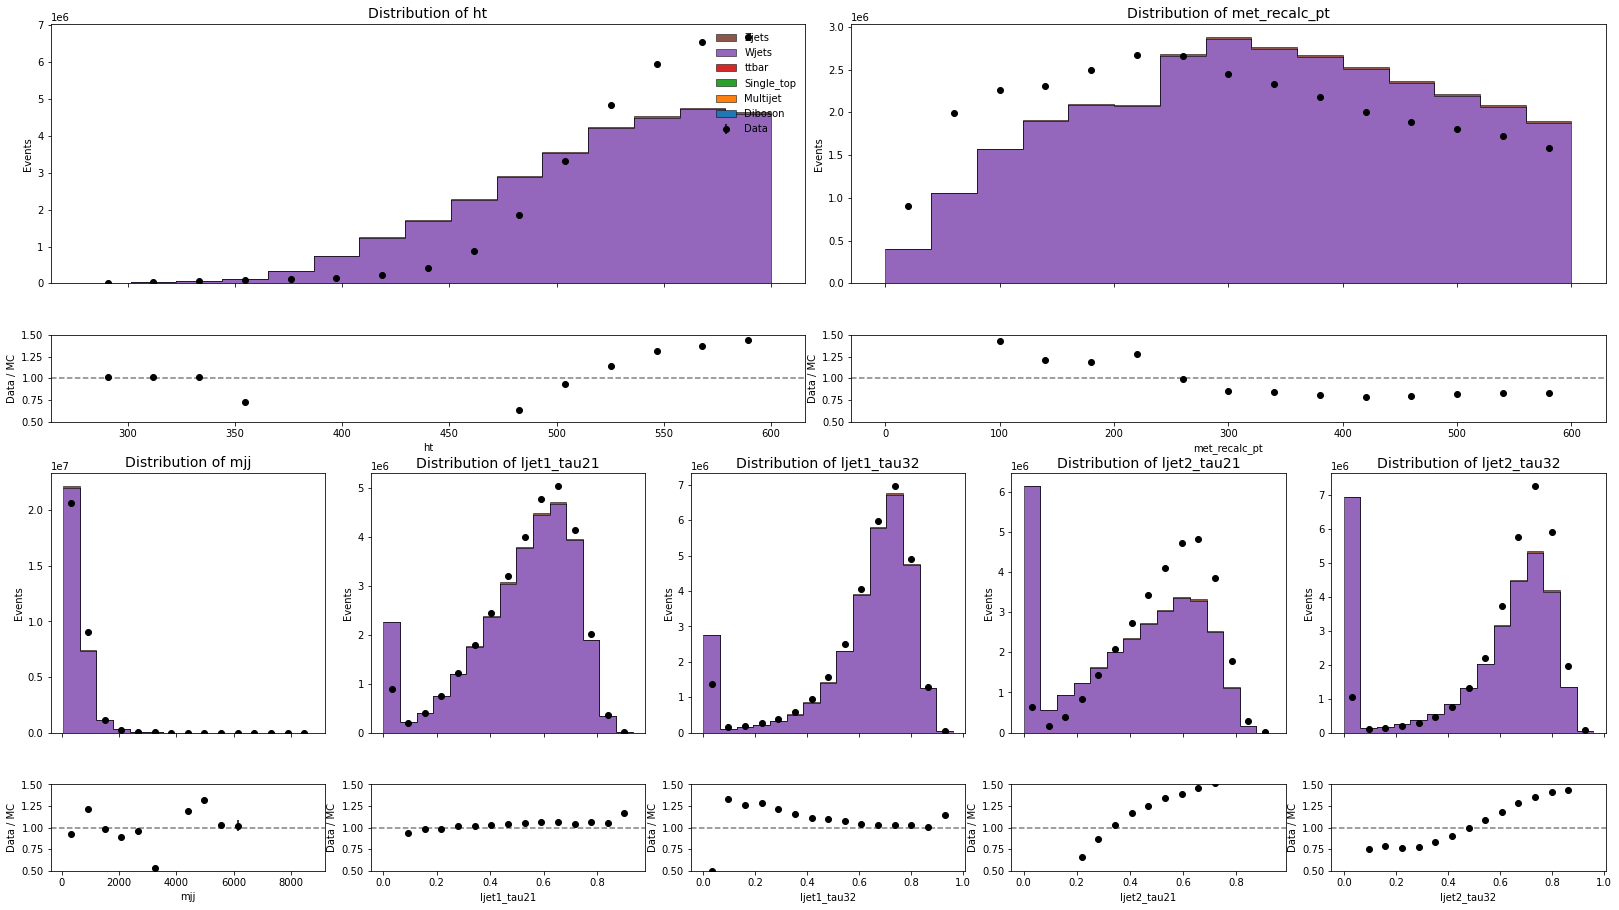

In [12]:
plot_mc_data_comparison(mc_total_df, data_total_df)


--- CR1L ---
Total Data Yield: 761448
Total MC Yield:   140877943.61
Applying Empirical Norm Factor: 0.00541
----------------------



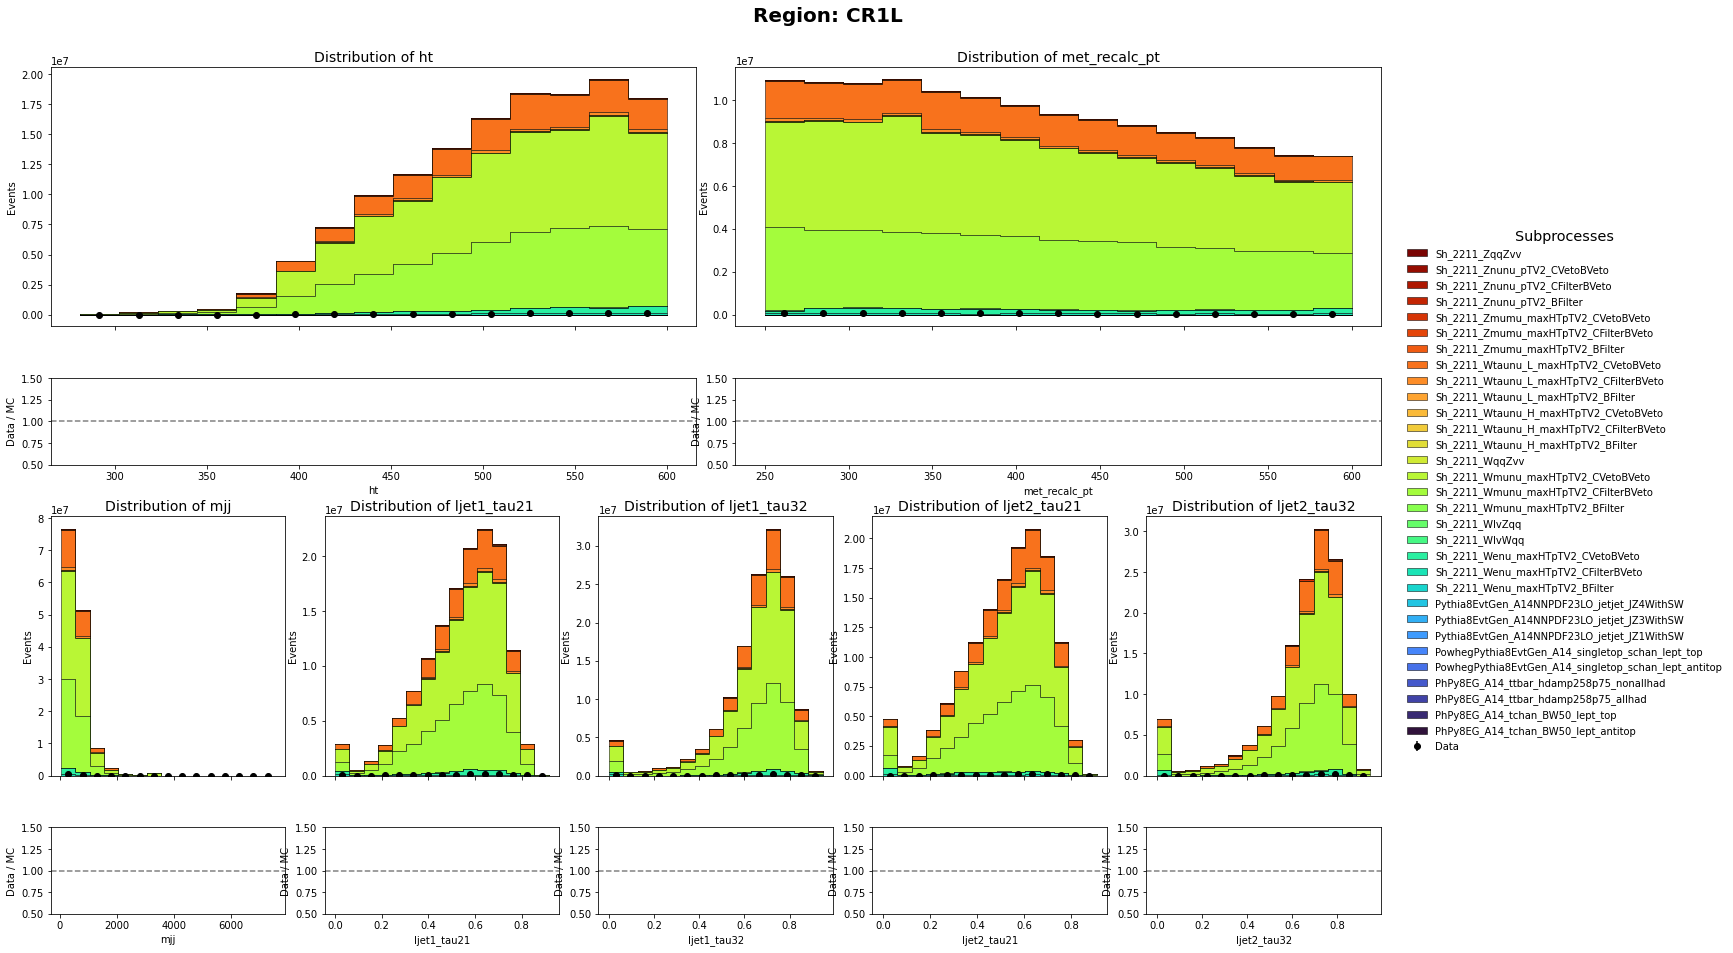

In [13]:
procs_to_remove = ["Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ1WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ3WithSW", "Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ4WithSW"]
df_mc = MC_CR1L.filter(~pl.col("subprocess").is_in(procs_to_remove))
with_meta_MC_CR1L = plot_subprocess_data_comparison(MC_CR1L, DATA_CR1L, region_name="CR1L")

In [14]:
wmunu_samples = with_meta_MC_CR1L.filter(
    pl.col("subprocess").str.contains("Wmunu")
)

In [15]:
wmunu_samples

mc_process,subprocess,raw_weights,weight_ngen,weight_sub_weight,weight_tot_weight,met_recalc_pt,met_recalc_phi,ht,mjj,ljet1_tau21,ljet1_tau32,ljet2_tau21,ljet2_tau32,crossSection_pb,genFiltEff,kFactor,sumOfWeights,official_scale_factor,final_weight
str,str,f32,f64,f32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64
"""Wjets""","""Sh_2211_Wmunu_maxHTpTV2_CFilte…",2331777.5,7.745788,3.0953e-10,5.8636e-8,341.142426,-2.53054,570.686523,413.655334,0.548274,0.746309,0.725848,0.690645,21806.0,0.1460112,1.0,9.4439e15,0.000134,312.737607
"""Wjets""","""Sh_2211_Wmunu_maxHTpTV2_CFilte…",-8.755155e6,7.745788,3.0953e-10,5.8636e-8,572.634155,-1.837815,581.123108,462.020081,0.402273,0.416223,0.653617,0.540349,21806.0,0.1460112,1.0,9.4439e15,0.000134,-1174.239918
"""Wjets""","""Sh_2211_Wmunu_maxHTpTV2_CFilte…",1.3939e6,7.745788,3.0953e-10,5.8636e-8,540.932251,2.374967,477.196869,460.721893,0.549507,0.34415,0.612156,0.545178,21806.0,0.1460112,1.0,9.4439e15,0.000134,186.953238
"""Wjets""","""Sh_2211_Wmunu_maxHTpTV2_CFilte…",-1.0317134e7,7.745788,3.0953e-10,5.8636e-8,574.411926,1.131093,564.72876,422.305359,0.423792,0.659597,0.59661,0.744766,21806.0,0.1460112,1.0,9.4439e15,0.000134,-1383.732279
"""Wjets""","""Sh_2211_Wmunu_maxHTpTV2_CFilte…",1.707427e6,7.745788,3.0953e-10,5.8636e-8,580.655029,-2.248887,564.29071,1400.067017,0.232913,0.479115,0.49101,0.654068,21806.0,0.1460112,1.0,9.4439e15,0.000134,228.999822
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Wjets""","""Sh_2211_Wmunu_maxHTpTV2_BFilte…",-1.0216e6,60.321802,6.1830e-9,0.000001,590.331421,0.243031,590.32605,825.009338,0.477118,0.602027,0.613628,0.486142,21806.0,0.0097968,1.0,4.3698e14,0.000009,-9.193463
"""Wjets""","""Sh_2211_Wmunu_maxHTpTV2_BFilte…",1917800.5,60.321802,6.1830e-9,0.000001,373.406403,1.405717,485.079193,428.946808,0.506704,0.786562,0.617511,0.577177,21806.0,0.0097968,1.0,4.3698e14,0.000009,17.25816
"""Wjets""","""Sh_2211_Wmunu_maxHTpTV2_BFilte…",4.916924e6,60.321802,6.1830e-9,0.000001,418.948547,-2.985897,563.726196,554.19519,0.607326,0.693066,0.599603,0.597148,21806.0,0.0097968,1.0,4.3698e14,0.000009,44.247075


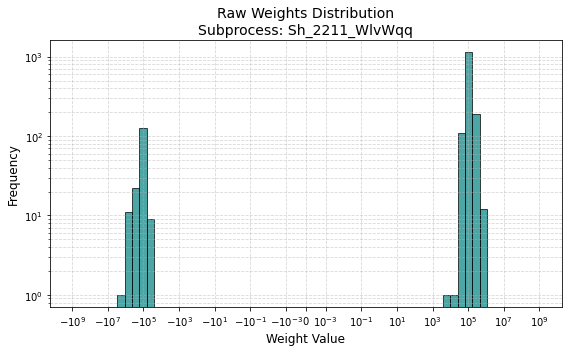

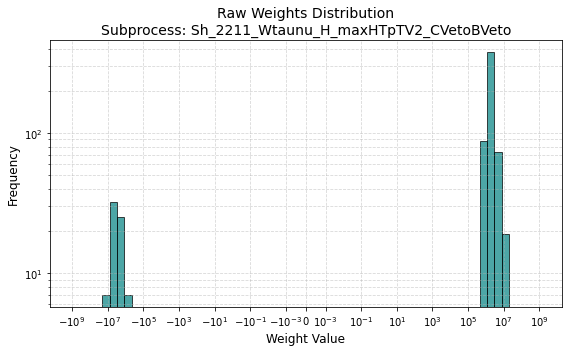

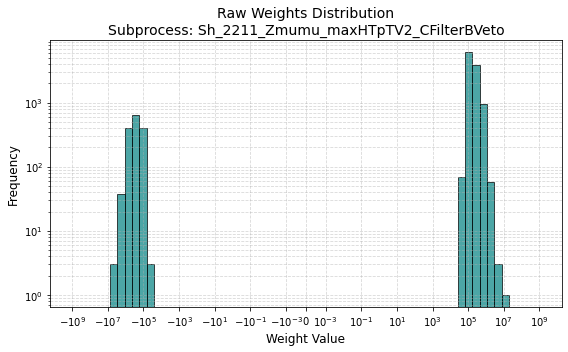

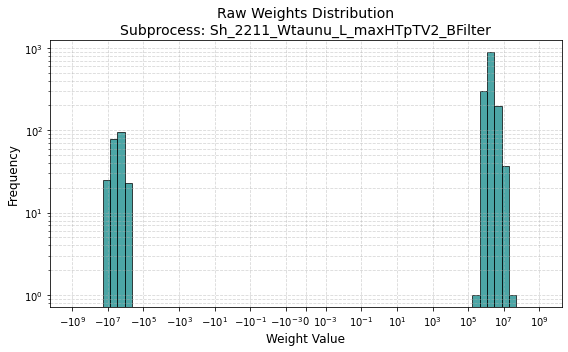

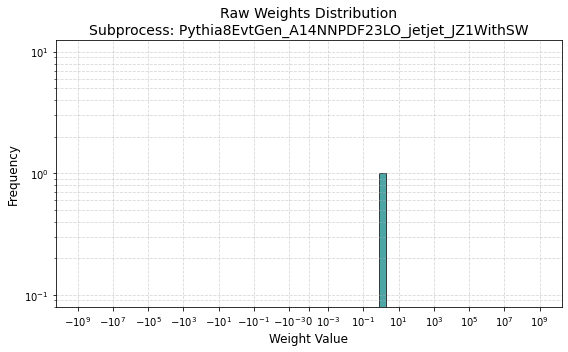

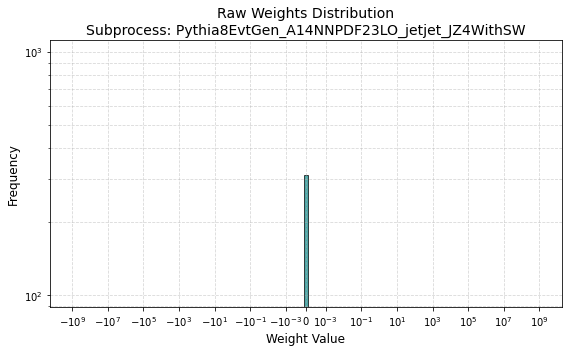

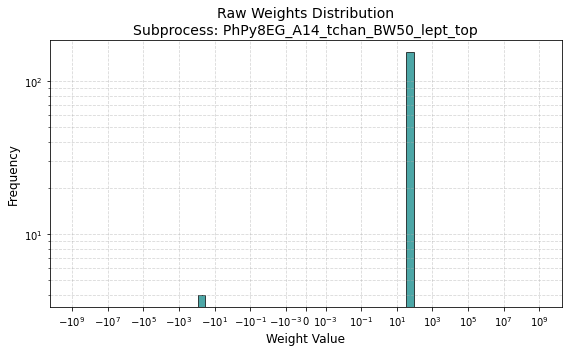

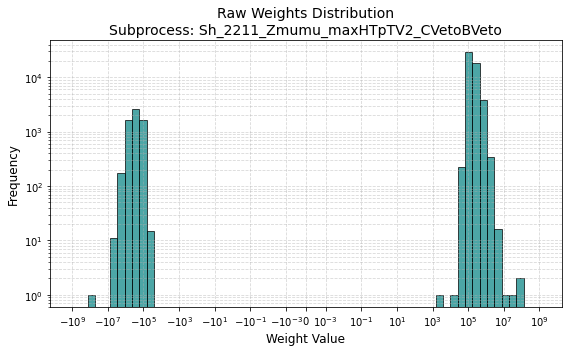

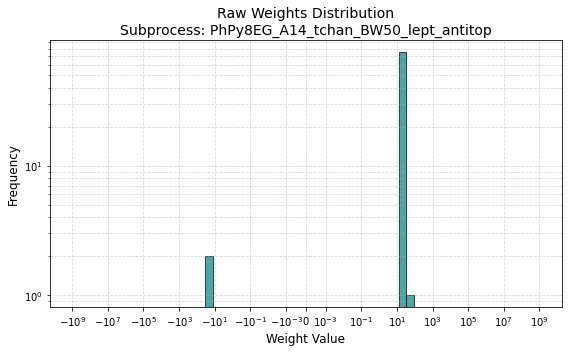

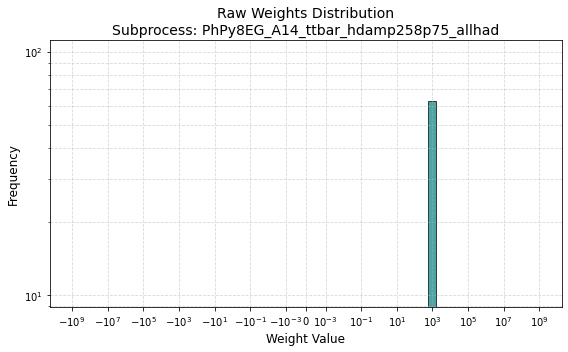

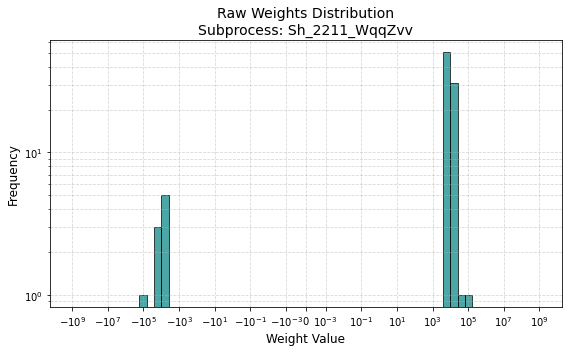

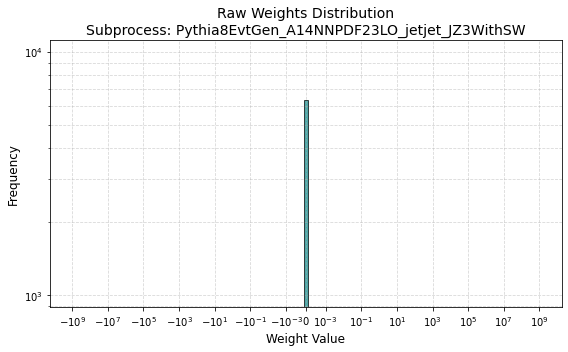

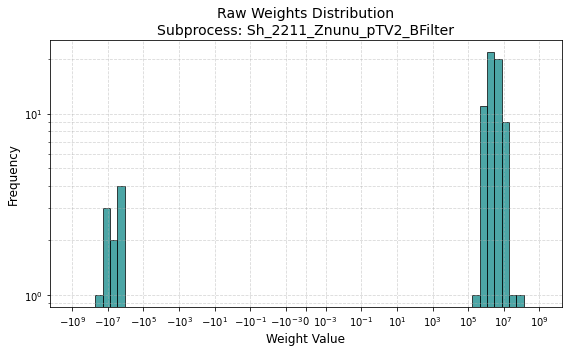

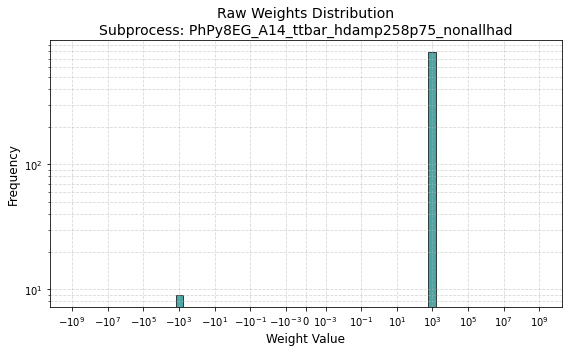

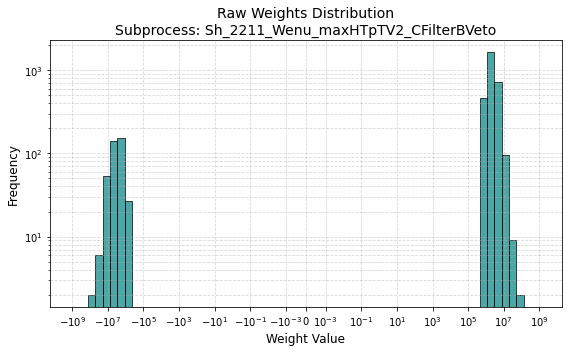

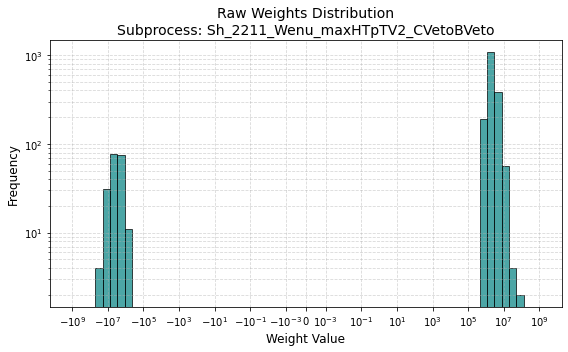

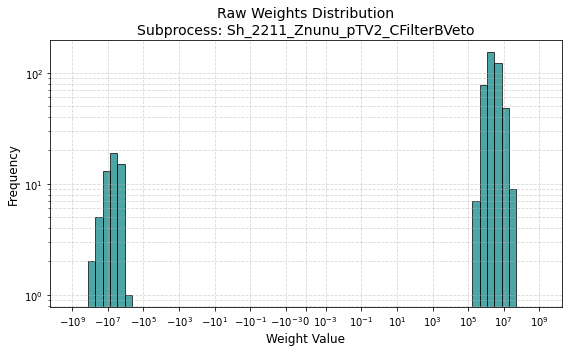

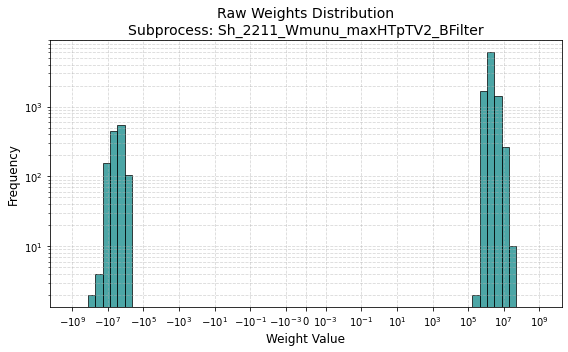

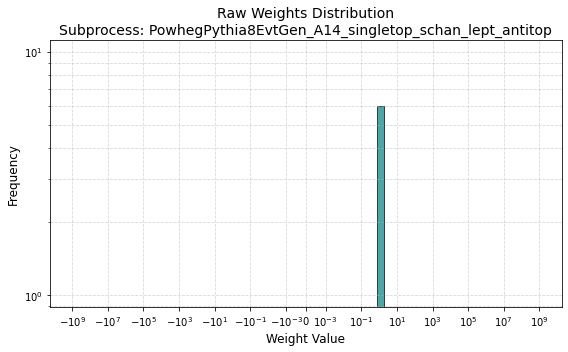

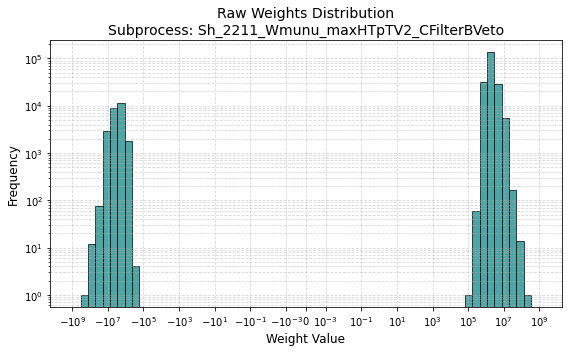

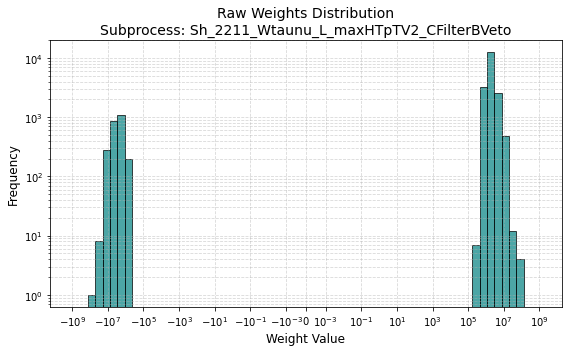

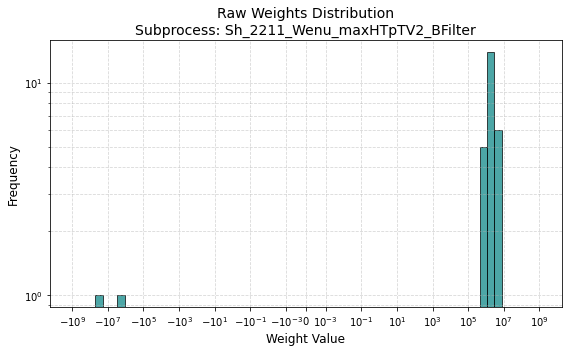

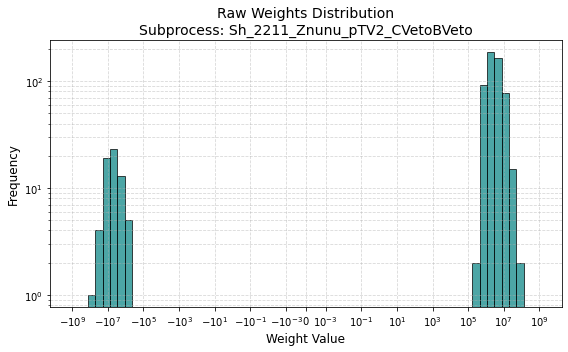

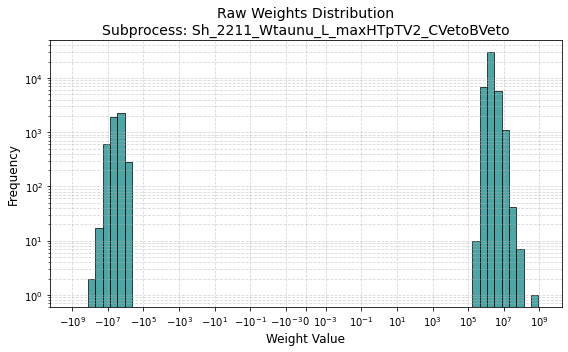

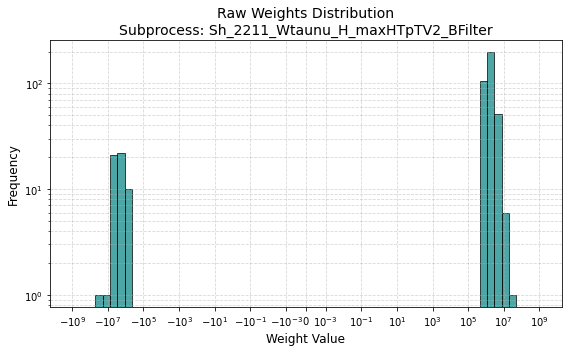

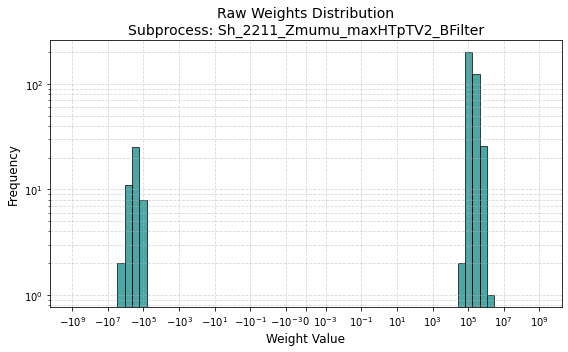

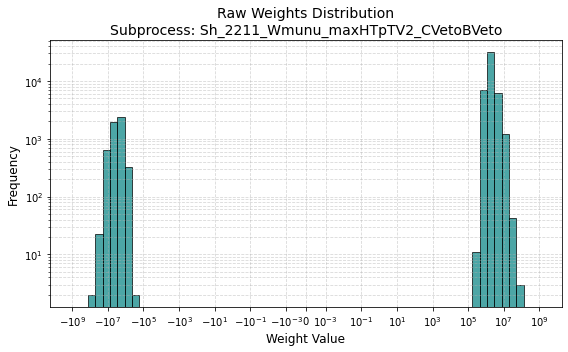

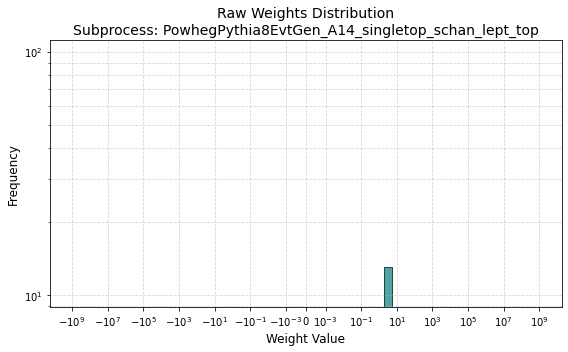

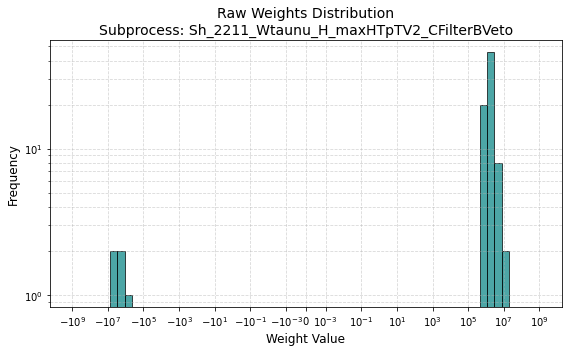

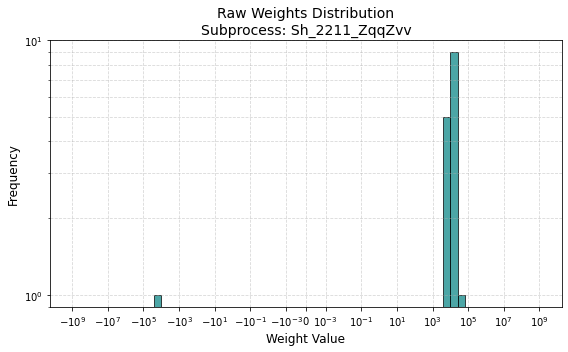

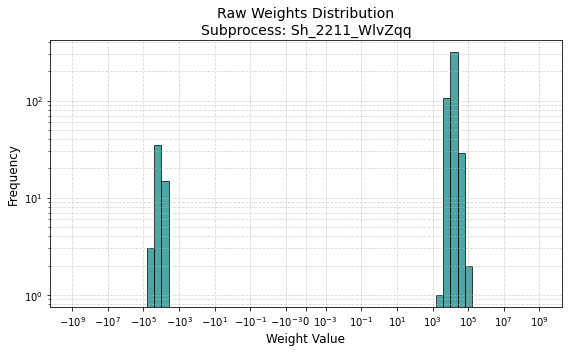

In [16]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# 1. Get unique subprocesses
subprocesses = with_meta_MC_CR1L["subprocess"].unique().to_list()

# 2. Setup consistent bins across all plots
# Getting the global max ensures the x-axis scale is the same for comparison
global_max_val = with_meta_MC_CR1L.select(pl.col("raw_weights").abs().max()).item()
lin_thresh = 1e-3 

neg_bins = -np.logspace(np.log10(global_max_val), np.log10(lin_thresh), 30)
lin_bins = np.linspace(-lin_thresh, lin_thresh, 10)
pos_bins = np.logspace(np.log10(lin_thresh), np.log10(global_max_val), 30)

symlog_bins = np.unique(np.concatenate([neg_bins, lin_bins, pos_bins]))

# 3. Loop through and create INDIVIDUAL plots
for sp in subprocesses:
    # Filter weights for the current subprocess
    weights = MC_CR1L.filter(pl.col("subprocess") == sp)["raw_weights"].to_numpy()
    
    # Create a new figure for each subprocess
    plt.figure(figsize=(8, 5))
    
    # Plot as a filled histogram since there's no overlap to worry about
    plt.hist(weights, bins=symlog_bins, color='teal', alpha=0.7, edgecolor='black')

    # Apply scales
    plt.xscale('symlog', linthresh=lin_thresh)
    plt.yscale('log')

    # Formatting tailored to the individual subprocess
    plt.xlabel('Weight Value', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Raw Weights Distribution\nSubprocess: {sp}', fontsize=14)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.tight_layout()
    
    # Show the plot before moving to the next subprocess
    plt.show()

In [17]:
sum_weights_df = MC_CR1L.group_by("subprocess").agg(
    pl.sum("raw_weights").alias("sum_raw_weights")
)

print("Sum of raw_weights per subprocess:")
with pl.Config(tbl_rows=-1):
    print(sum_weights_df)

Sum of raw_weights per subprocess:
shape: (31, 2)
┌─────────────────────────────────┬─────────────────┐
│ subprocess                      ┆ sum_raw_weights │
│ ---                             ┆ ---             │
│ str                             ┆ f32             │
╞═════════════════════════════════╪═════════════════╡
│ PhPy8EG_A14_tchan_BW50_lept_to… ┆ 5669.07373      │
│ Sh_2211_Wtaunu_H_maxHTpTV2_CVe… ┆ 9.993728e8      │
│ PowhegPythia8EvtGen_A14_single… ┆ 26.362299       │
│ Sh_2211_WlvWqq                  ┆ 1.51955248e8    │
│ Sh_2211_WqqZvv                  ┆ 718858.0        │
│ PowhegPythia8EvtGen_A14_single… ┆ 7.6046          │
│ Sh_2211_Wtaunu_L_maxHTpTV2_CVe… ┆ 7.7977e10       │
│ Sh_2211_Wenu_maxHTpTV2_CVetoBV… ┆ 3.7463e9        │
│ Sh_2211_Znunu_pTV2_CVetoBVeto   ┆ 2.1809e9        │
│ Pythia8EvtGen_A14NNPDF23LO_jet… ┆ 1.0             │
│ PhPy8EG_A14_tchan_BW50_lept_an… ┆ 1699.35498      │
│ Pythia8EvtGen_A14NNPDF23LO_jet… ┆ 0.000147        │
│ Sh_2211_Wtaunu_L_maxHTpTV2_CFi

In [18]:
sum_weights_df

subprocess,sum_raw_weights
str,f32
"""PhPy8EG_A14_tchan_BW50_lept_to…",5669.07373
"""Sh_2211_Wtaunu_H_maxHTpTV2_CVe…",9.993728e8
"""PowhegPythia8EvtGen_A14_single…",26.362299
"""Sh_2211_WlvWqq""",1.51955248e8
"""Sh_2211_WqqZvv""",718858.0
…,…
"""Sh_2211_Znunu_pTV2_CFilterBVet…",1.1985e9
"""Sh_2211_Wtaunu_H_maxHTpTV2_BFi…",5.49602944e8
"""Sh_2211_Zmumu_maxHTpTV2_CVetoB…",9.1254e9


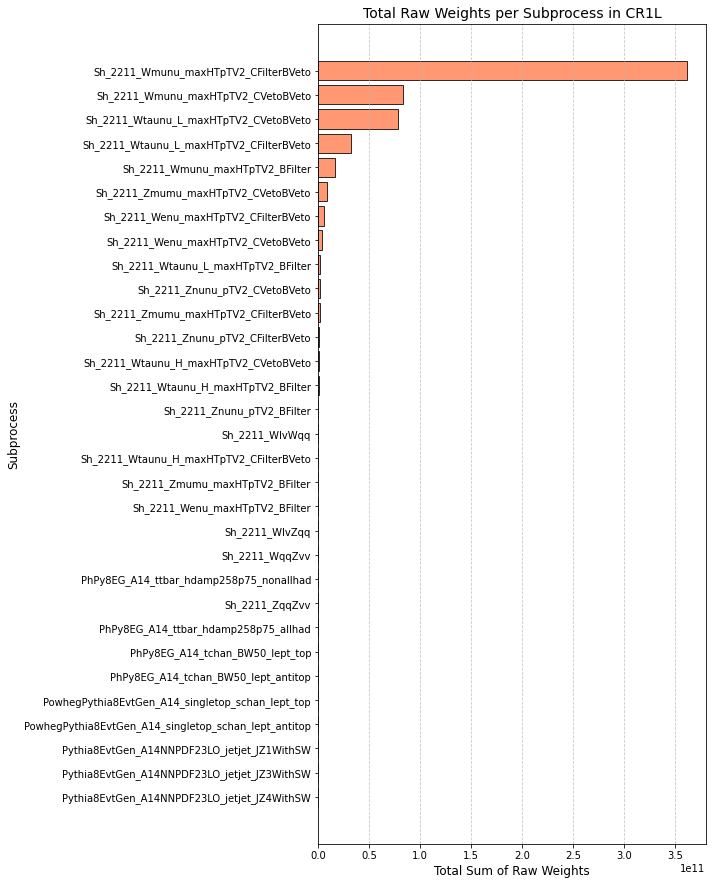

In [19]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Ensure the sums are calculated (in case you haven't run this recently)
sum_weights_df = with_meta_MC_CR1L.group_by("subprocess").agg(
    pl.sum("raw_weights").alias("sum_raw_weights")
)

# 2. Sort the dataframe so the largest weights are at the top (makes it much easier to read)
sum_weights_sorted = sum_weights_df.sort("sum_raw_weights", descending=False)

# Extract columns to lists for plotting
subprocesses = sum_weights_sorted["subprocess"].to_list()
total_weights = sum_weights_sorted["sum_raw_weights"].to_list()

# 3. Dynamic Figure Height: allocate about 0.4 inches of vertical space per subprocess
# (Ensures that even if you have 50 subprocesses, the bars won't be squished)
fig_height = max(6, len(subprocesses) * 0.4)
plt.figure(figsize=(10, fig_height))

# 4. Create the horizontal bar chart
plt.barh(subprocesses, total_weights, color='coral', edgecolor='black', alpha=0.8)

# 5. Formatting
plt.xlabel('Total Sum of Raw Weights', fontsize=12)
plt.ylabel('Subprocess', fontsize=12)
plt.title('Total Raw Weights per Subprocess in CR1L', fontsize=14)

# Add vertical grid lines to make it easier to read the values
plt.grid(axis='x', linestyle='--', alpha=0.7)

# This prevents the long subprocess names from being chopped off on the left side
plt.tight_layout()

plt.show()

In [20]:
import uproot

events = uproot.open("/home/aegis/ether/Research_HEP/Dataset_ver4/MC/reduce_root/Diboson/mc20_13TeV_MC_Sh_2211_WlvWqq/root_0.root:CollectionTree").arrays(library="ak")

In [21]:
events["EventInfoAuxDyn_mcEventWeights"]

<Array [[1.97e+05, 7.96e-15, ..., 1.97e+05], ...] type='160000 * var * float32'>

In [22]:
MC_CR0L_test = MC_CR0L.filter(
    pl.col("met_recalc_pt") >= 300
)
DATA_CR0L_test = DATA_CR0L.filter(
    pl.col("met_recalc_pt") >= 300
)

Generating plots for: 1-Lepton CR (W+jets dominated)

---  ---
Total Data Yield: 761448
Total MC Yield:   140877863.31
Applying Empirical Norm Factor: 0.00541
----------------------



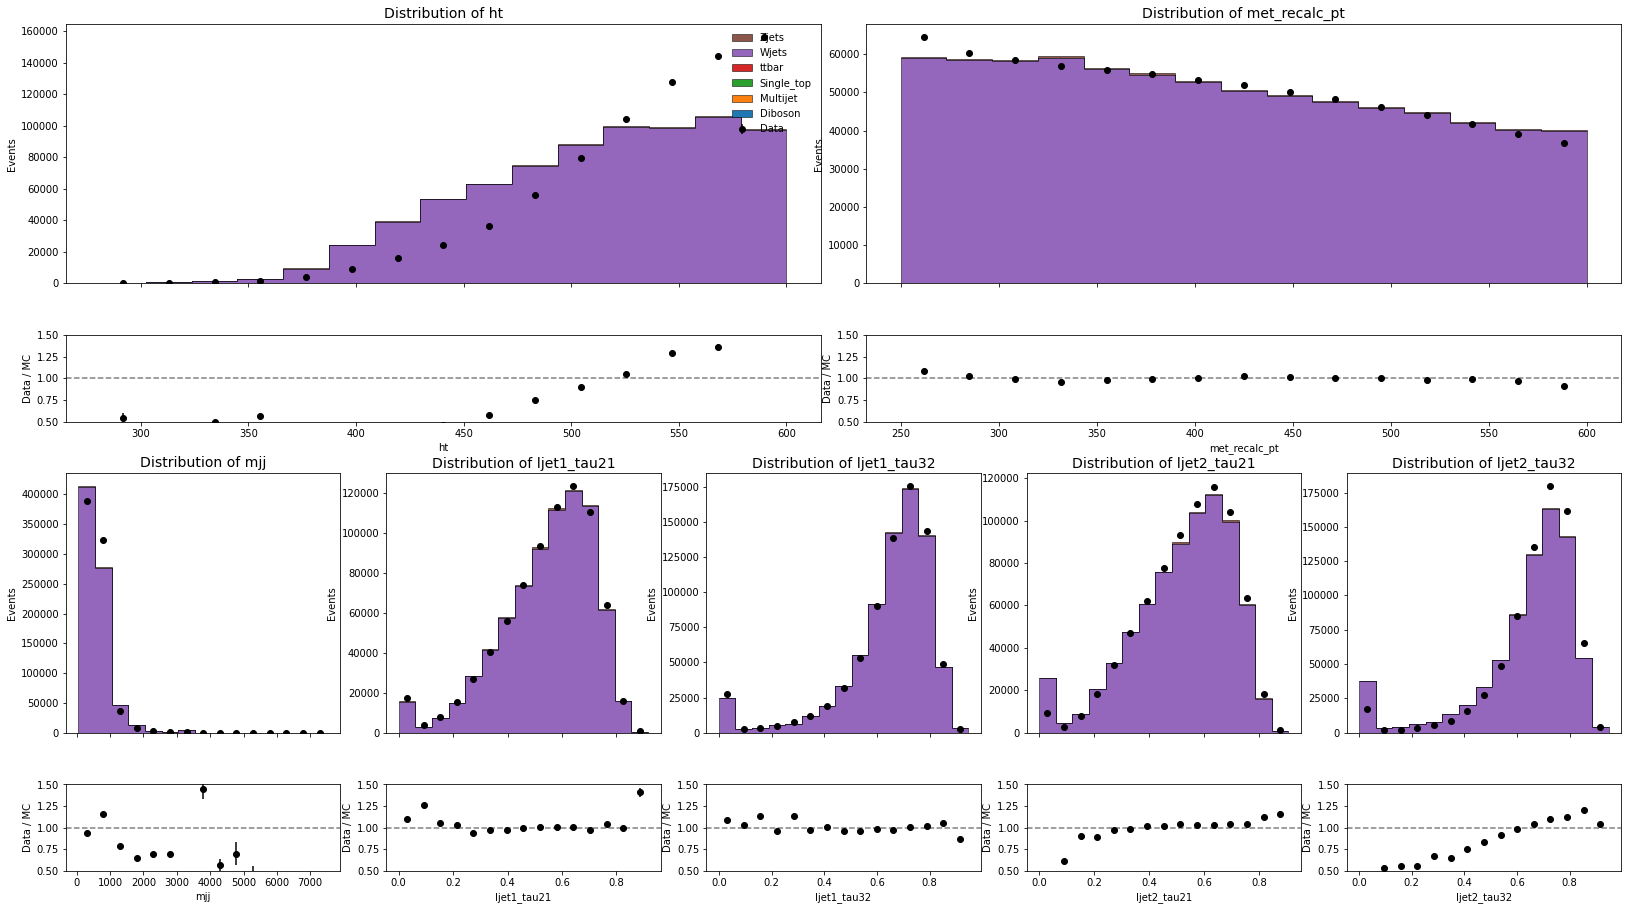

Generating plots for: 1-Lepton 1-Btag CR (Top dominated)

---  ---
Total Data Yield: 749146
Total MC Yield:   69019033.14
Applying Empirical Norm Factor: 0.01085
----------------------



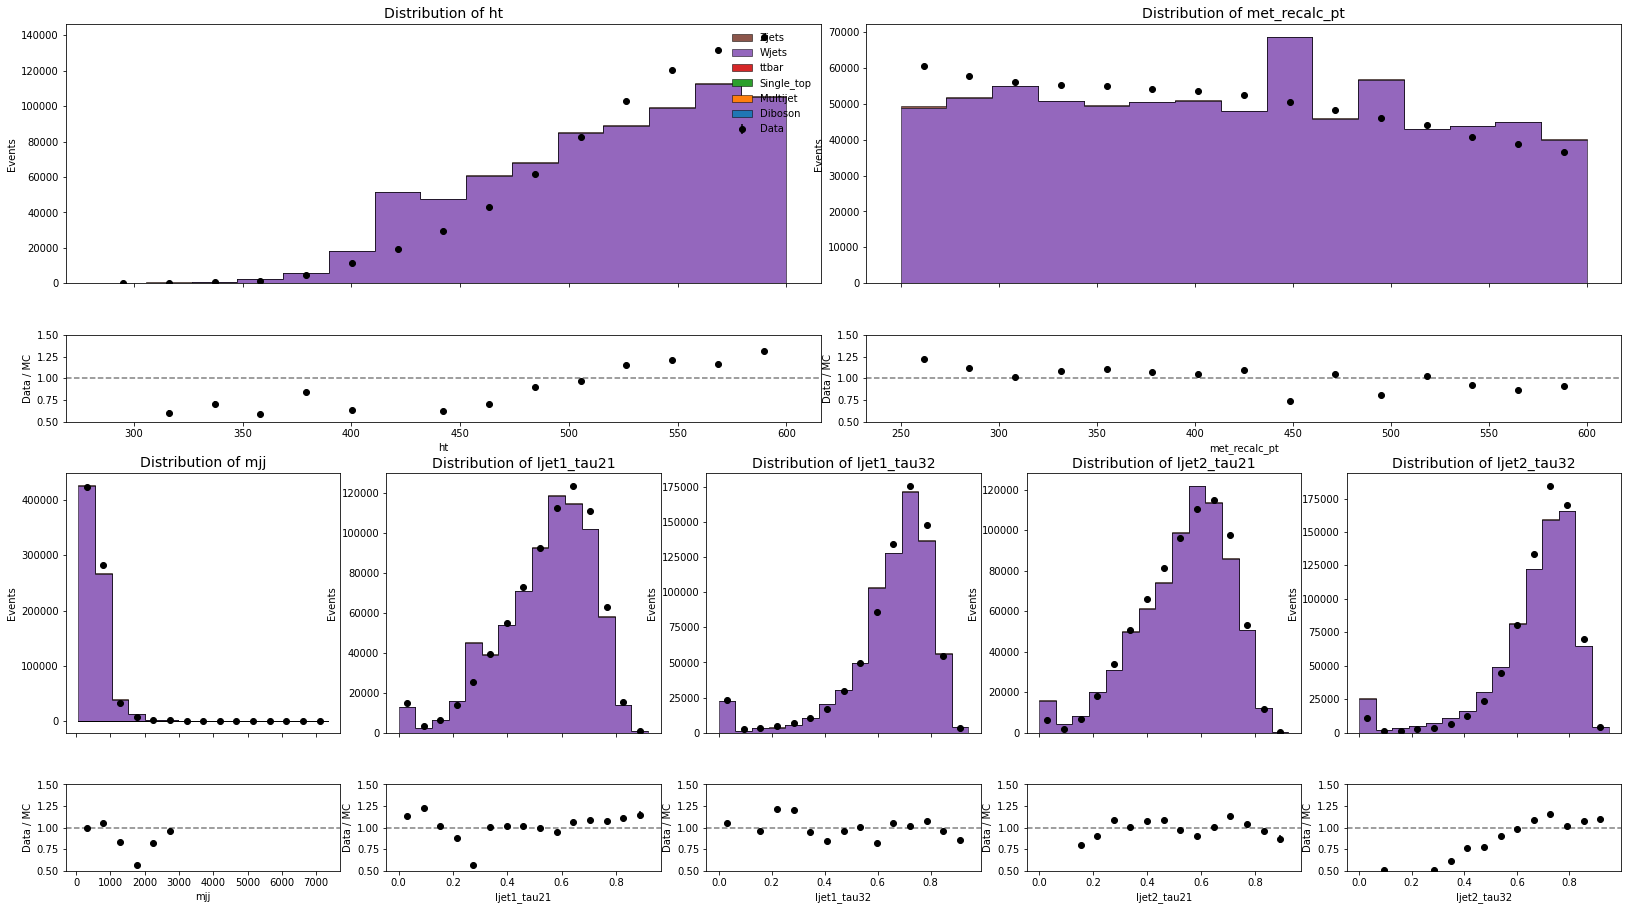

Generating plots for: 2-Lepton CR (Z+jets dominated)

---  ---
Total Data Yield: 43227
Total MC Yield:   65997312.98
Applying Empirical Norm Factor: 0.00065
----------------------



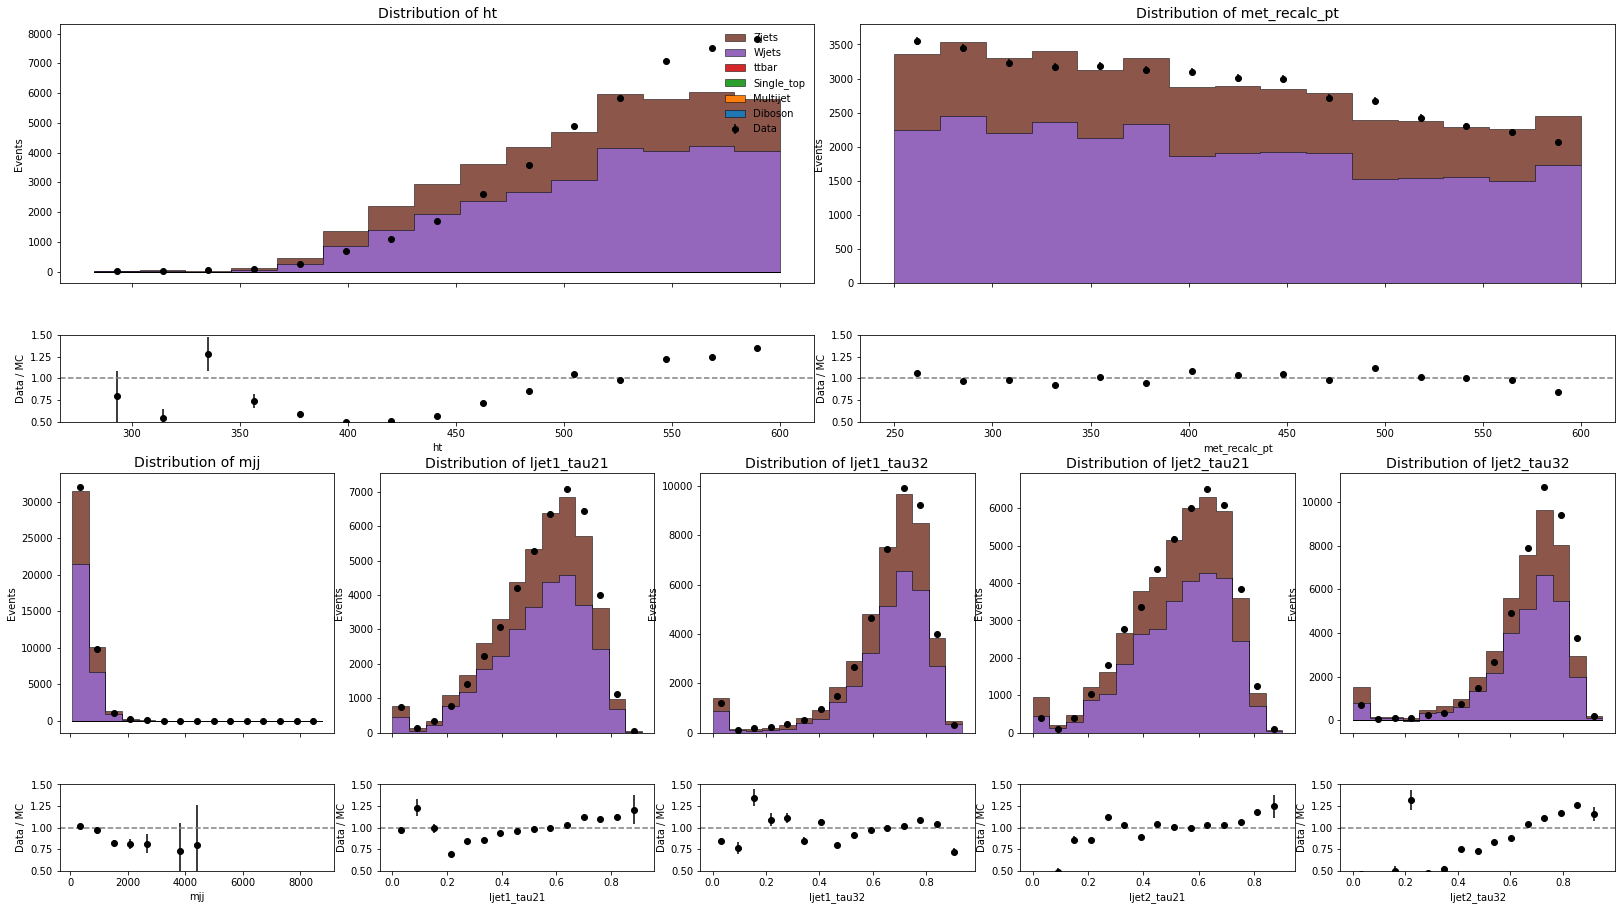

Generating plots for: 0-Lepton CR (Multijet dominated)

---  ---
Total Data Yield: 13422461
Total MC Yield:   199778412.12
Applying Empirical Norm Factor: 0.06719
----------------------



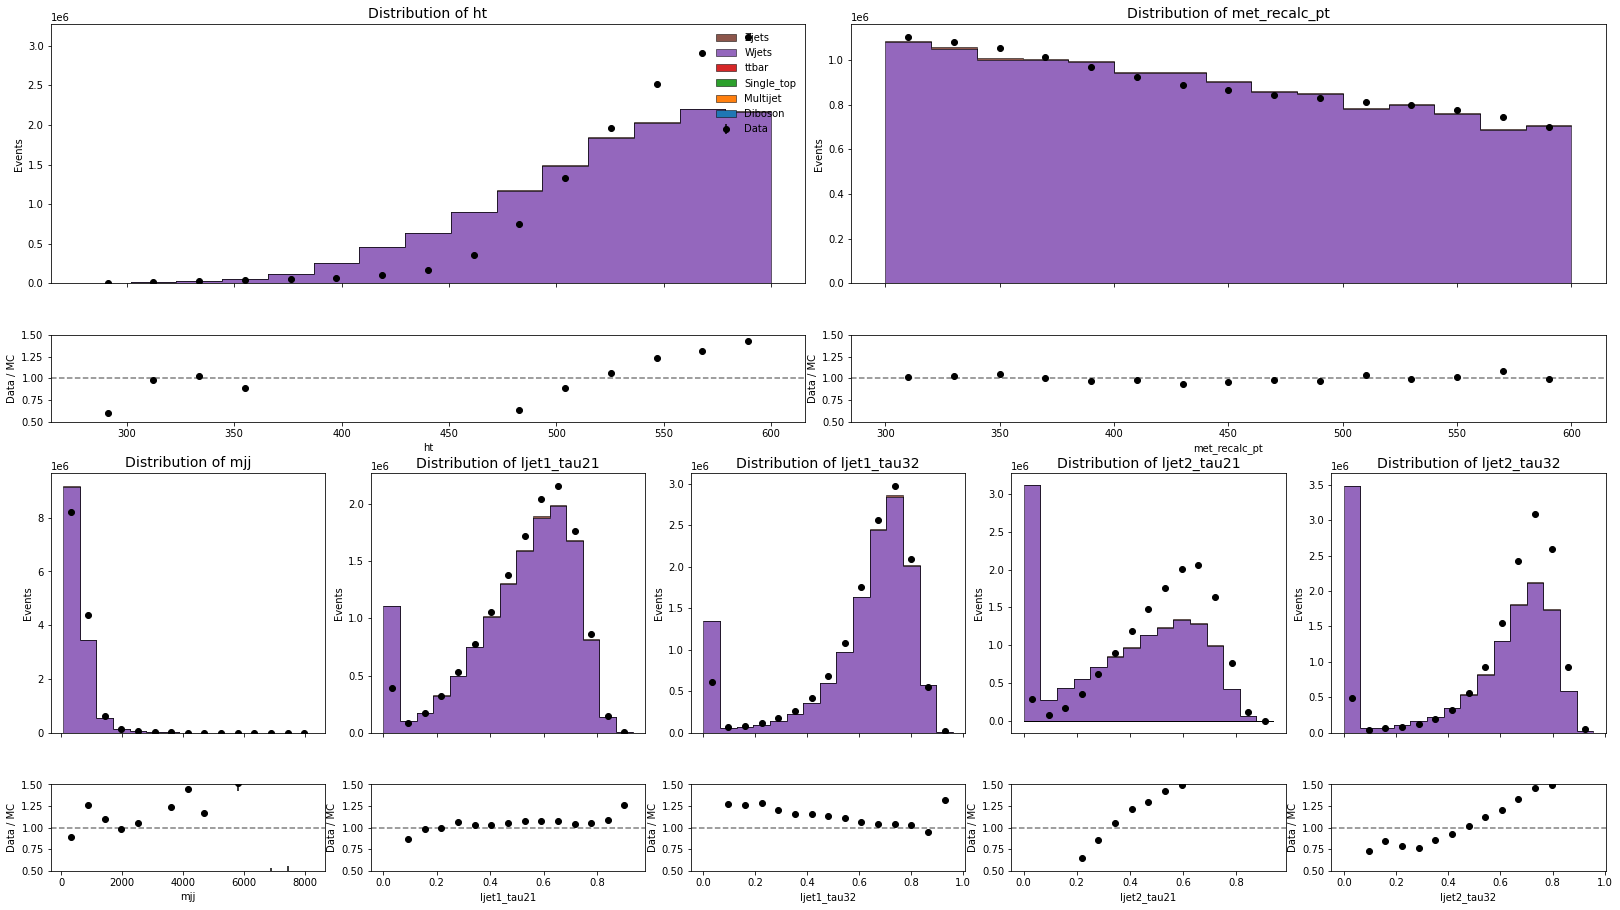

In [23]:
# Group your pre-loaded DataFrames by region
regions = {
    "1-Lepton CR (W+jets dominated)": (df_mc, DATA_CR1L),
    "1-Lepton 1-Btag CR (Top dominated)": (MC_CR1L1B, DATA_CR1L1B),
    "2-Lepton CR (Z+jets dominated)": (MC_CR2L, DATA_CR2L),
    "0-Lepton CR (Multijet dominated)": (MC_CR0L_test, DATA_CR0L_test)
}

# Plot each region independently
for region_name, (mc_df, data_df) in regions.items():
    print(f"Generating plots for: {region_name}")
    
    # Optional: You can pass region_name to plot_mc_data_comparison 
    # to use it in your ax_main.set_title() so you know which plot is which!
    plot_mc_data_comparison(mc_df, data_df)

### Split and Scale Samples

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib  # For saving the scaler

# MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR2L1B, MC_CR0L, MC_SR
# DATA_CR1L, DATA_CR1L1B, DATA_CR2L, DATA_CR2L1B, DATA_CR0L, DATA_SR 

In [25]:
context_vars_m = ['met_recalc_pt', 'ht']
feature_vars_x = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']    

features_to_scale = context_vars_m + feature_vars_x

all_mc_df = pl.concat([MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR0L, MC_SR])
X_all_mc = all_mc_df.select(features_to_scale).to_numpy()

In [26]:
# 3. Calculate the global minimum and maximum for each feature
min_max_exprs = []
for f in features_to_scale:
    min_max_exprs.append(pl.col(f).min().alias(f"{f}_min"))
    min_max_exprs.append(pl.col(f).max().alias(f"{f}_max"))

print("Calculating global bounds across all MC...")
global_bounds = all_mc_df.select(min_max_exprs)
global_bounds.head()

Calculating global bounds across all MC...


met_recalc_pt_min,met_recalc_pt_max,ht_min,ht_max,mjj_min,mjj_max,ljet1_tau21_min,ljet1_tau21_max,ljet1_tau32_min,ljet1_tau32_max,ljet2_tau21_min,ljet2_tau21_max,ljet2_tau32_min,ljet2_tau32_max
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
0.249281,158313.421875,280.07782,13056.811523,56.356136,12967.166992,0.0,0.93062,0.0,0.958472,0.0,0.93041,0.0,0.960577


In [27]:
scaler = MinMaxScaler(feature_range=(-2.5, 2.5))
scaler.fit(X_all_mc) # The scaler now "remembers" the global MC min/max

X_MC_CR1L_scaled = scaler.transform(MC_CR1L.select(features_to_scale).to_numpy())
X_DATA_CR1L_scaled = scaler.transform(DATA_CR1L.select(features_to_scale).to_numpy())

In [28]:
import seaborn as sns

def plot_unscaled_features(df, title="Feature Distributions Before Scaling"):
    """
    Plots the context variables on the first row and feature variables on the second row.
    Accepts a Polars DataFrame.
    """
    # Set the overall figure size
    fig = plt.figure(figsize=(24, 10))
    fig.suptitle(title, fontsize=20, fontweight='bold', y=0.98)

    # ==========================================
    # ROW 1: Context Variables (2 columns wide)
    # ==========================================
    # index 1 and 2 in a 2x2 grid occupy the top row
    ax_ht = fig.add_subplot(2, 2, 1)
    sns.histplot(df['ht'].to_numpy(), bins=80, color='skyblue', ax=ax_ht, edgecolor='none')
    ax_ht.set_title("HT (Context Variable)", fontsize=16)
    ax_ht.set_xlabel("HT [GeV]")
    ax_ht.set_ylabel("Density")
    ax_ht.set_yscale("log")

    ax_met = fig.add_subplot(2, 2, 2)
    # print(max(df['met_recalc_pt'].to_numpy()))
    sns.histplot(df['met_recalc_pt'].to_numpy(), bins=80, color='salmon', ax=ax_met, edgecolor='none')
    ax_met.set_title("MET (Context Variable)", fontsize=16)
    ax_met.set_xlabel("Missing ET [GeV]")
    ax_met.set_ylabel("Density")
    ax_met.set_yscale("log")
    # ==========================================
    # ROW 2: Feature Variables (5 columns wide)
    # ==========================================
    # indices 6 through 10 in a 2x5 grid occupy the bottom row
    ax_mjj = fig.add_subplot(2, 5, 6)
    sns.histplot(df['mjj'].to_numpy(), bins=60, color='lightgreen', ax=ax_mjj, edgecolor='none')
    ax_mjj.set_title("Dijet Mass (mjj)", fontsize=14)
    ax_mjj.set_xlabel("mjj [GeV]")
    ax_mjj.set_yscale("log")

    ax_t21_1 = fig.add_subplot(2, 5, 7)
    sns.histplot(df['ljet1_tau21'].to_numpy(), bins=60, color='orange', ax=ax_t21_1, edgecolor='none')
    ax_t21_1.set_title("Leading Jet τ21", fontsize=14)
    ax_t21_1.set_xlabel("ljet1_tau21")

    ax_t32_1 = fig.add_subplot(2, 5, 8)
    sns.histplot(df['ljet1_tau32'].to_numpy(), bins=60, color='purple', ax=ax_t32_1, edgecolor='none')
    ax_t32_1.set_title("Leading Jet τ32", fontsize=14)
    ax_t32_1.set_xlabel("ljet1_tau32")

    ax_t21_2 = fig.add_subplot(2, 5, 9)
    sns.histplot(df['ljet2_tau21'].to_numpy(), bins=60, color='gold', ax=ax_t21_2, edgecolor='none')
    ax_t21_2.set_title("Sub-leading Jet τ21", fontsize=14)
    ax_t21_2.set_xlabel("ljet2_tau21")

    ax_t32_2 = fig.add_subplot(2, 5, 10)
    sns.histplot(df['ljet2_tau32'].to_numpy(), bins=60, color='teal', ax=ax_t32_2, edgecolor='none')
    ax_t32_2.set_title("Sub-leading Jet τ32", fontsize=14)
    ax_t32_2.set_xlabel("ljet2_tau32")

    # Clean up layout to prevent overlapping text
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


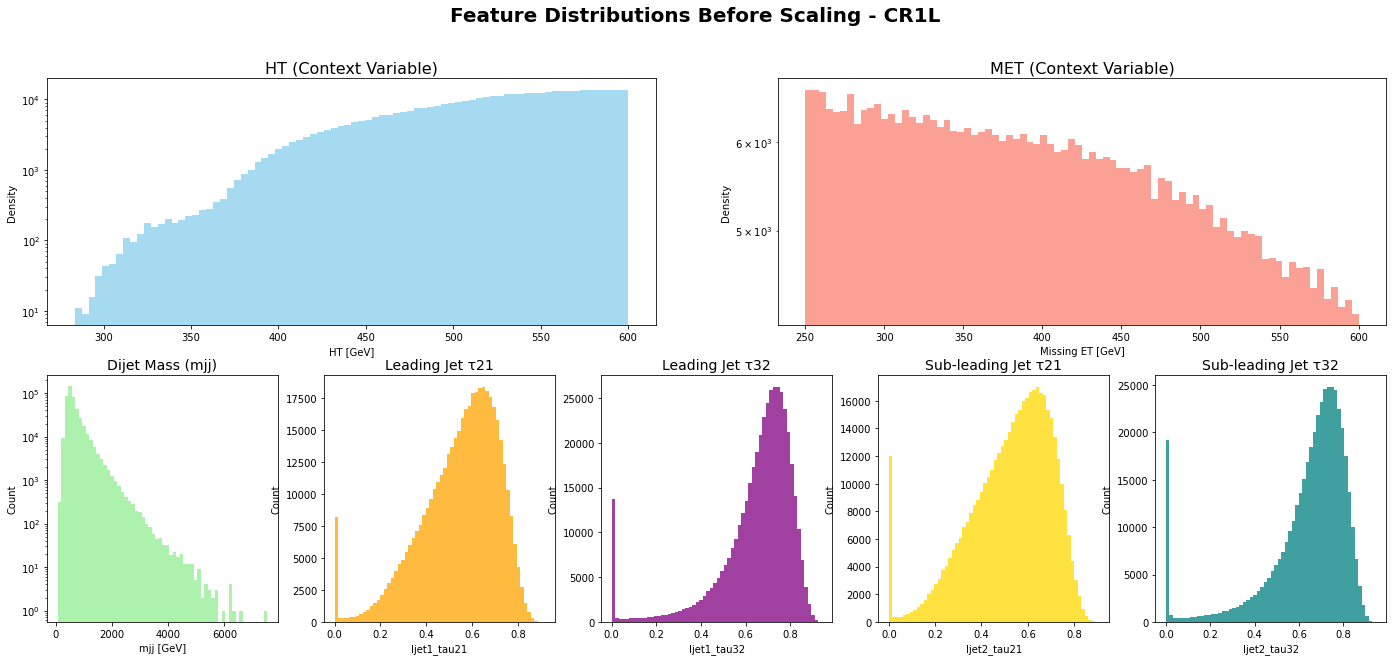

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


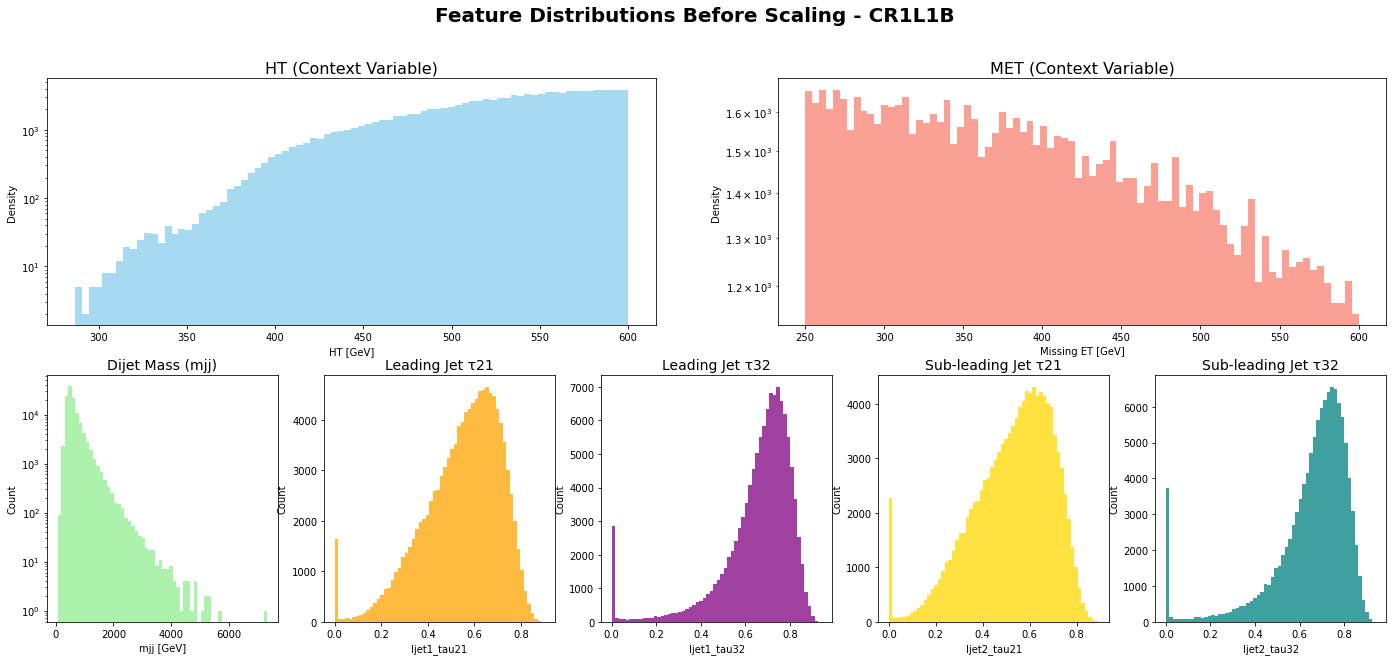

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


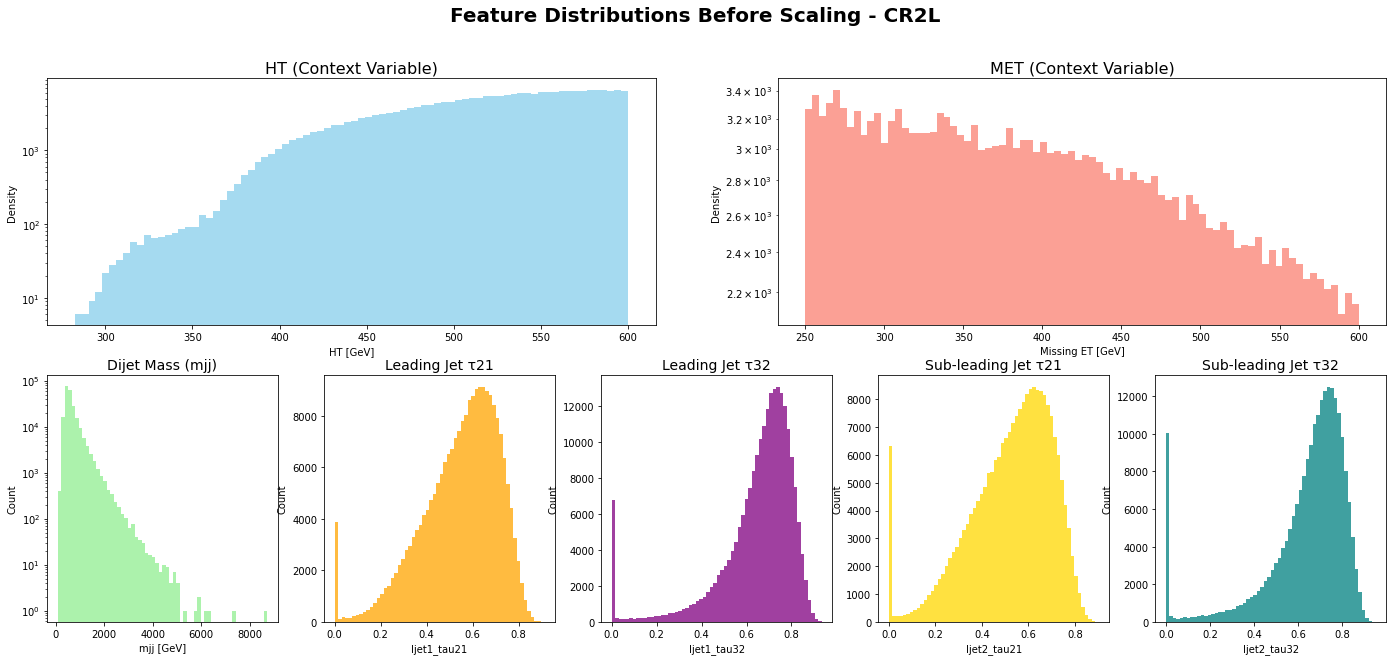

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


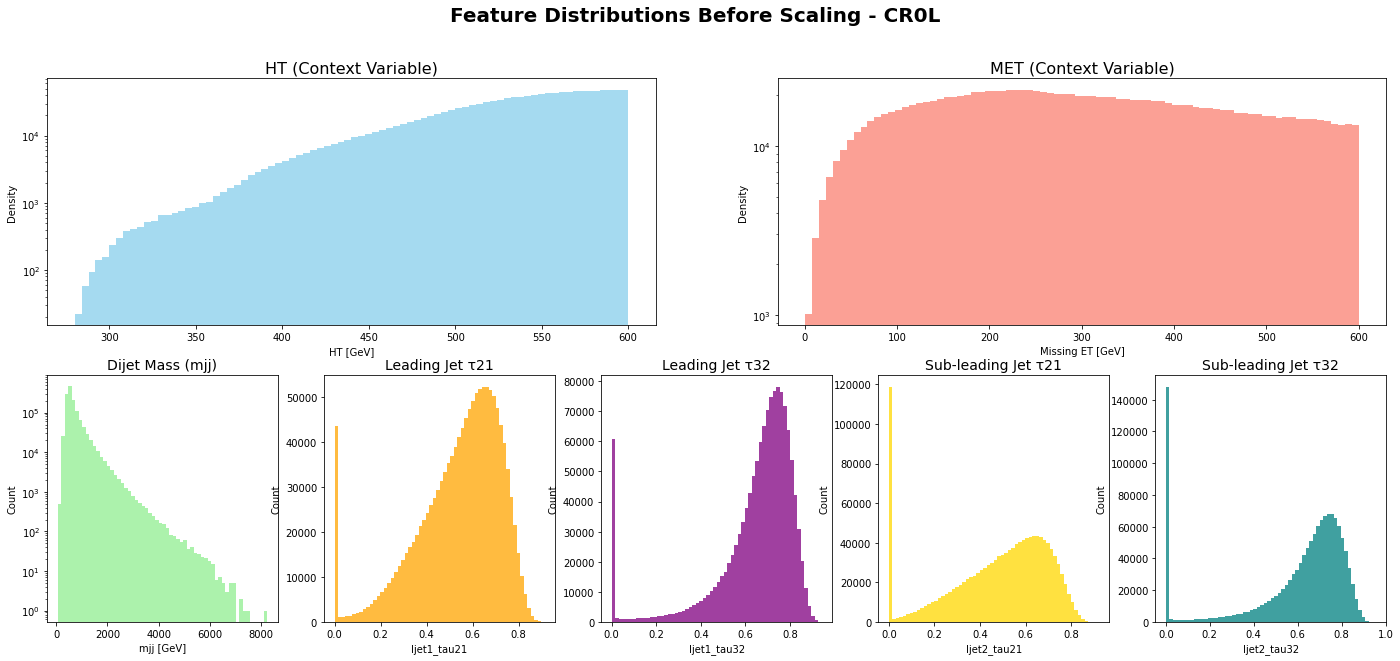

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


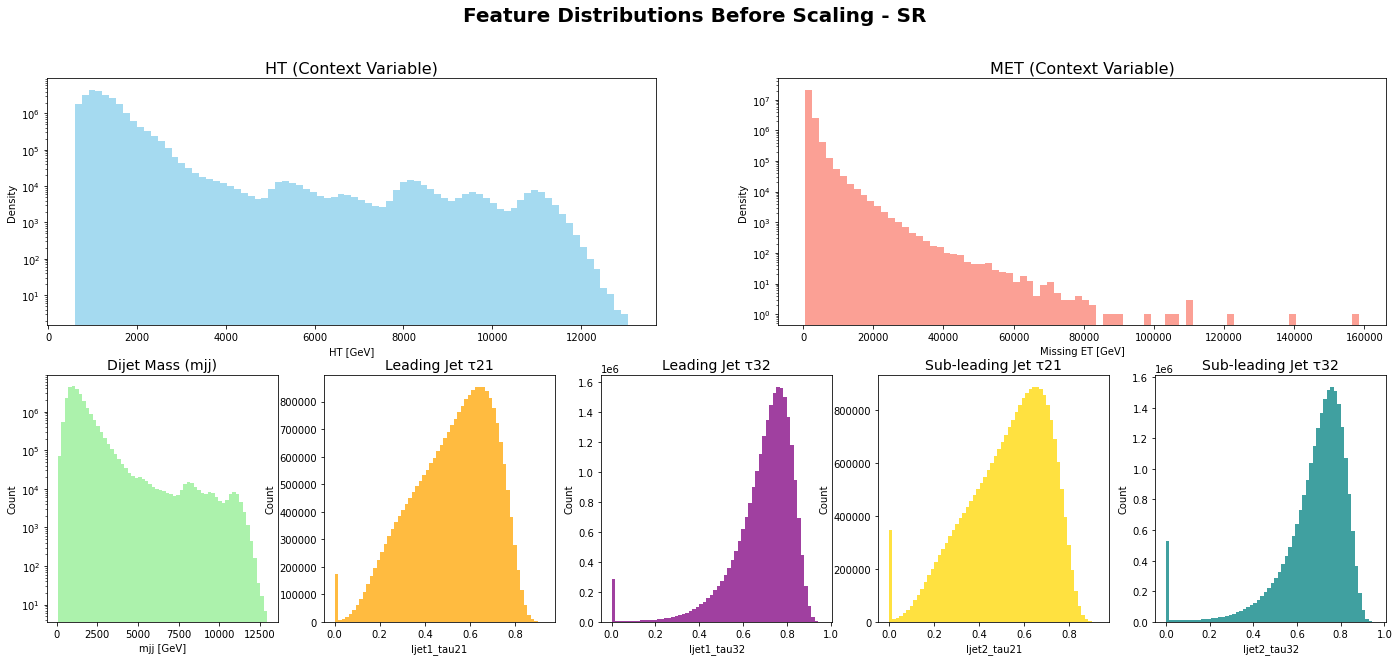

In [29]:
MC_SR_clean = MC_SR.filter(pl.col("met_recalc_pt") < 10000)
names = ["CR1L", "CR1L1B", "CR2L", "CR0L", "SR"]
for df, name in zip([MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR0L, MC_SR], names):
    plot_unscaled_features(df, title=f"Feature Distributions Before Scaling - {name}")

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


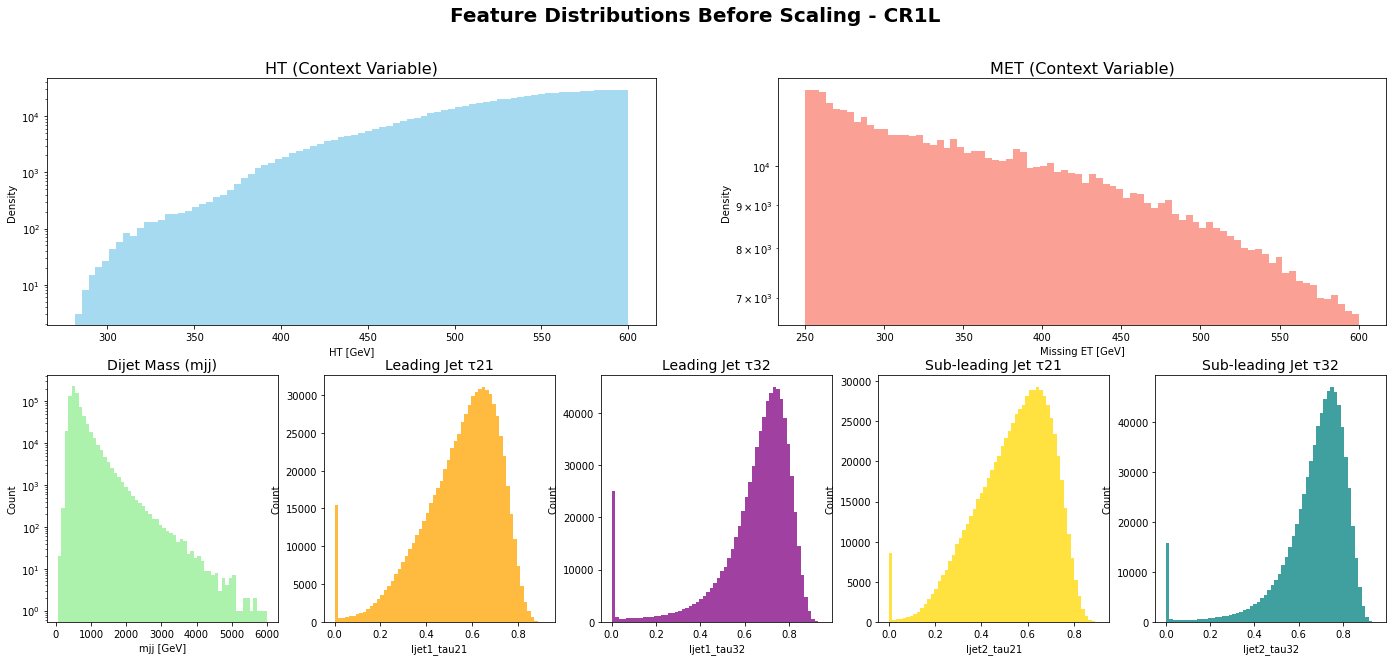

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


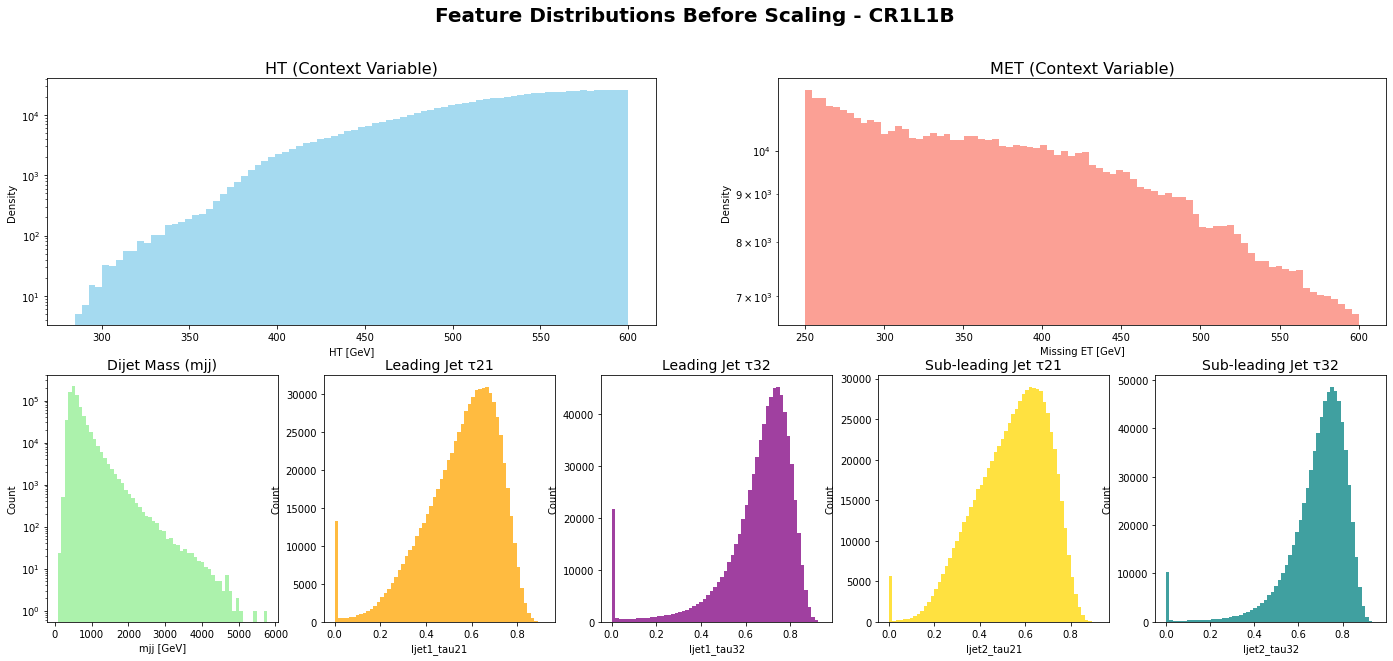

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


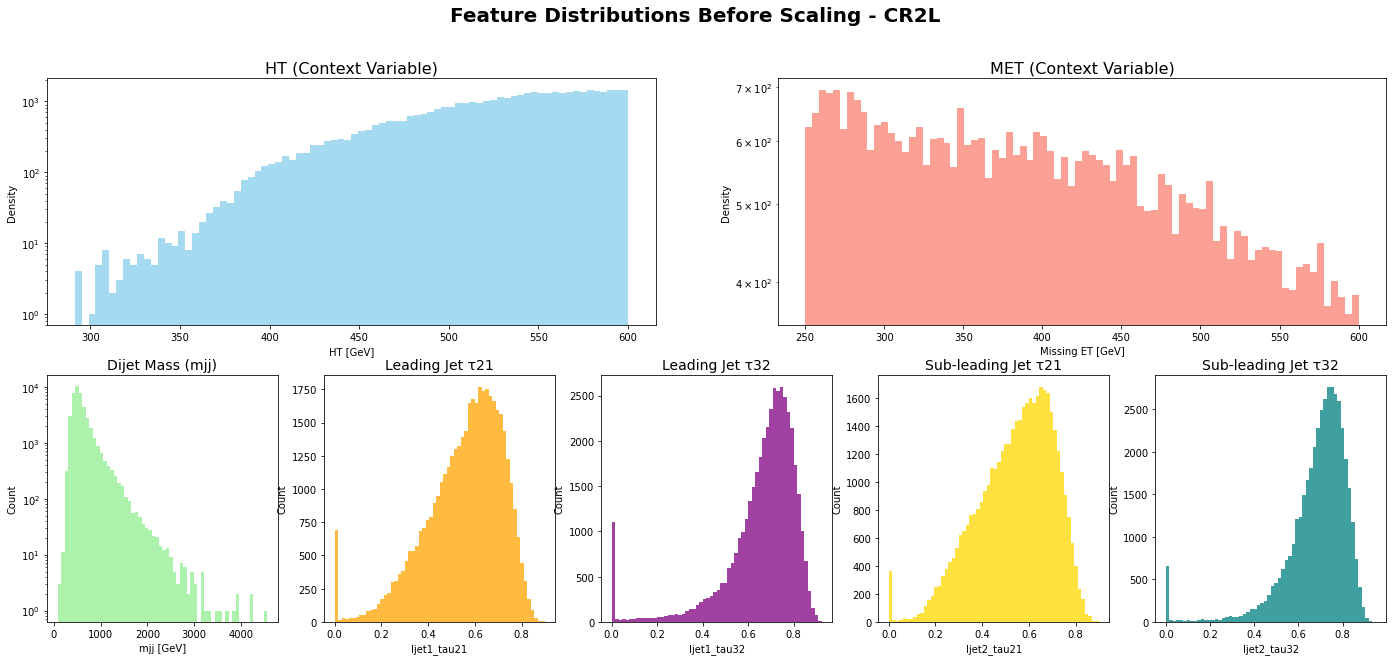

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


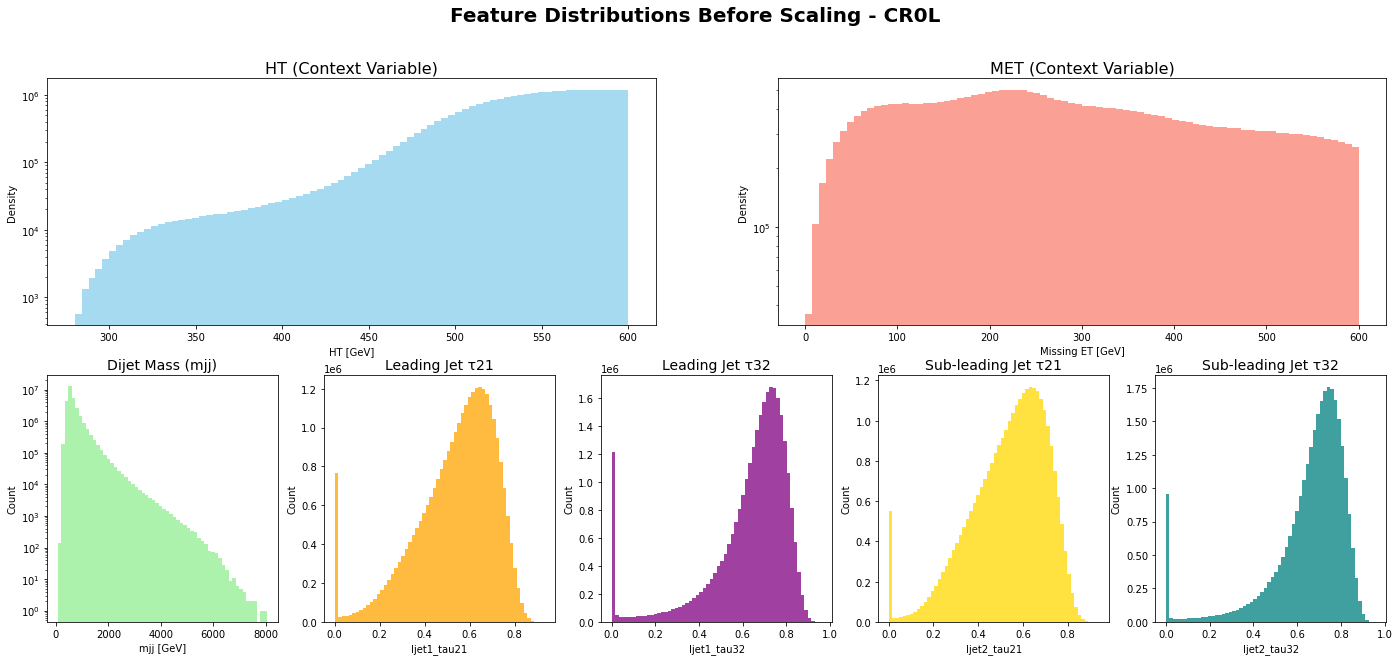

/tmp/ipykernel_173854/2972047040.py:61: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


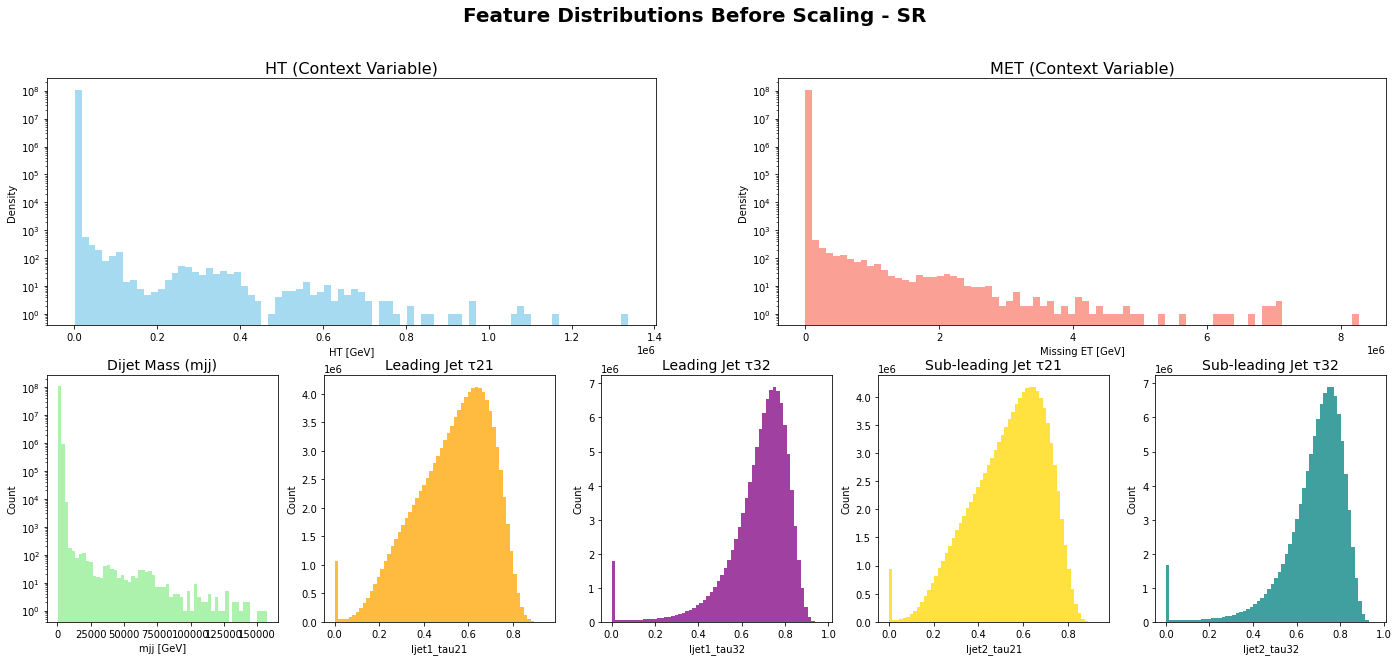

In [30]:
DATA_SR_clean = DATA_SR.filter(
    (pl.col("met_recalc_pt") < 20000) & 
    (pl.col("mjj") < 10000) & 
    (pl.col("ht") < 10000)
)
names = ["CR1L", "CR1L1B", "CR2L", "CR0L", "SR"]
for df, name in zip([DATA_CR1L, DATA_CR1L1B, DATA_CR2L, DATA_CR0L, DATA_SR], names):
    plot_unscaled_features(df, title=f"Feature Distributions Before Scaling - {name}")

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_unscaled_features(df_mc, df_data, title="Feature Distributions Before Scaling"):
    """
    Plots the context variables on the first row and feature variables on the second row.
    Accepts two Polars DataFrames: df_mc and df_data.
    """
    # Set the overall figure size
    fig = plt.figure(figsize=(24, 10))
    fig.suptitle(title, fontsize=20, fontweight='bold', y=0.98)

    # Helper function to plot both MC and Data on the same axis
    def plot_overlay(ax, col_name, title, xlabel, bins, mc_color):
        # Plot MC (filled)
        sns.histplot(df_mc[col_name].to_numpy(), bins=bins, color=mc_color, ax=ax, 
                     stat='density', edgecolor='none', alpha=0.6, label='MC')
        # Plot Data (step outline for visibility)
        sns.histplot(df_data[col_name].to_numpy(), bins=bins, color='black', ax=ax, 
                     stat='density', element='step', fill=False, label='Data')
        
        ax.set_title(title, fontsize=16 if 'Context' in title else 14)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        ax.set_yscale("log")
        ax.legend()

    # ==========================================
    # ROW 1: Context Variables (2 columns wide)
    # ==========================================
    # index 1 and 2 in a 2x2 grid occupy the top row
    ax_ht = fig.add_subplot(2, 2, 1)
    plot_overlay(ax_ht, 'ht', "HT (Context Variable)", "HT [GeV]", 80, 'skyblue')

    ax_met = fig.add_subplot(2, 2, 2)
    plot_overlay(ax_met, 'met_recalc_pt', "MET (Context Variable)", "Missing ET [GeV]", 80, 'salmon')

    # ==========================================
    # ROW 2: Feature Variables (5 columns wide)
    # ==========================================
    # indices 6 through 10 in a 2x5 grid occupy the bottom row
    ax_mjj = fig.add_subplot(2, 5, 6)
    plot_overlay(ax_mjj, 'mjj', "Dijet Mass (mjj)", "mjj [GeV]", 60, 'lightgreen')

    ax_t21_1 = fig.add_subplot(2, 5, 7)
    plot_overlay(ax_t21_1, 'ljet1_tau21', "Leading Jet τ21", "ljet1_tau21", 60, 'orange')

    ax_t32_1 = fig.add_subplot(2, 5, 8)
    plot_overlay(ax_t32_1, 'ljet1_tau32', "Leading Jet τ32", "ljet1_tau32", 60, 'purple')

    ax_t21_2 = fig.add_subplot(2, 5, 9)
    plot_overlay(ax_t21_2, 'ljet2_tau21', "Sub-leading Jet τ21", "ljet2_tau21", 60, 'gold')

    ax_t32_2 = fig.add_subplot(2, 5, 10)
    plot_overlay(ax_t32_2, 'ljet2_tau32', "Sub-leading Jet τ32", "ljet2_tau32", 60, 'teal')

    # Clean up layout to prevent overlapping text
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

/tmp/ipykernel_173854/2070168937.py:57: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


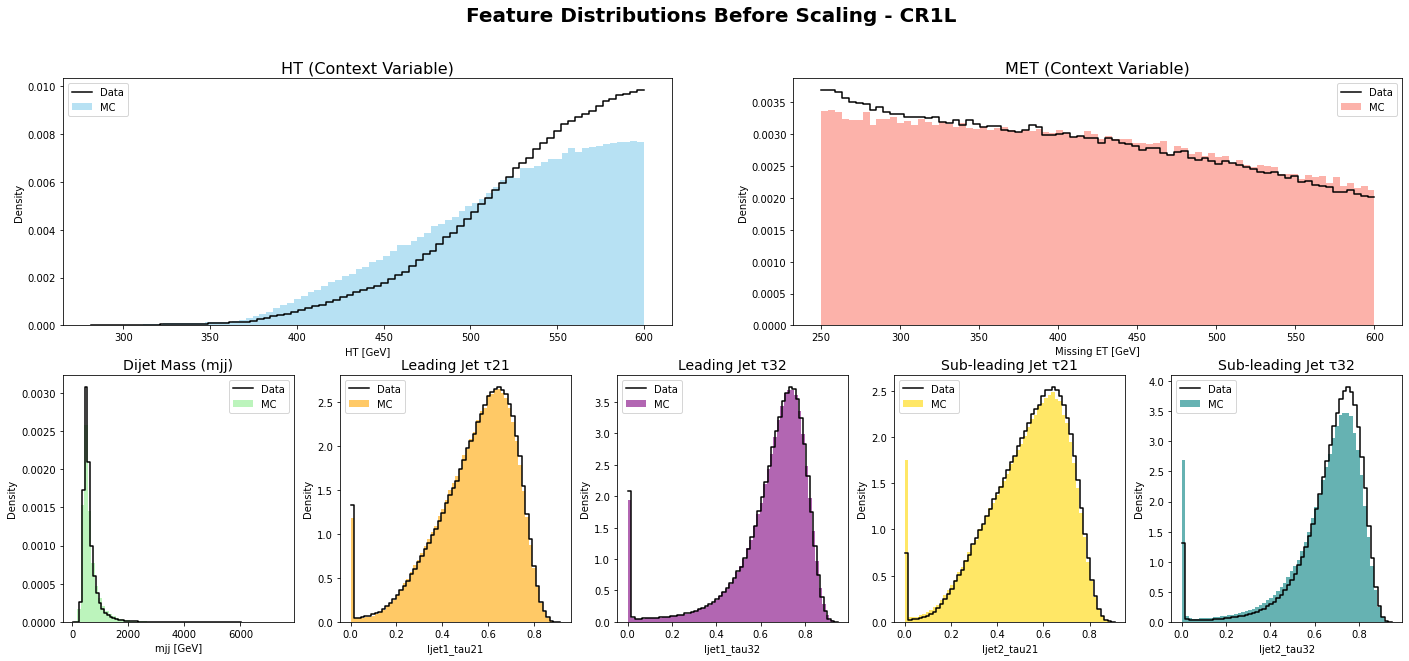

/tmp/ipykernel_173854/2070168937.py:57: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


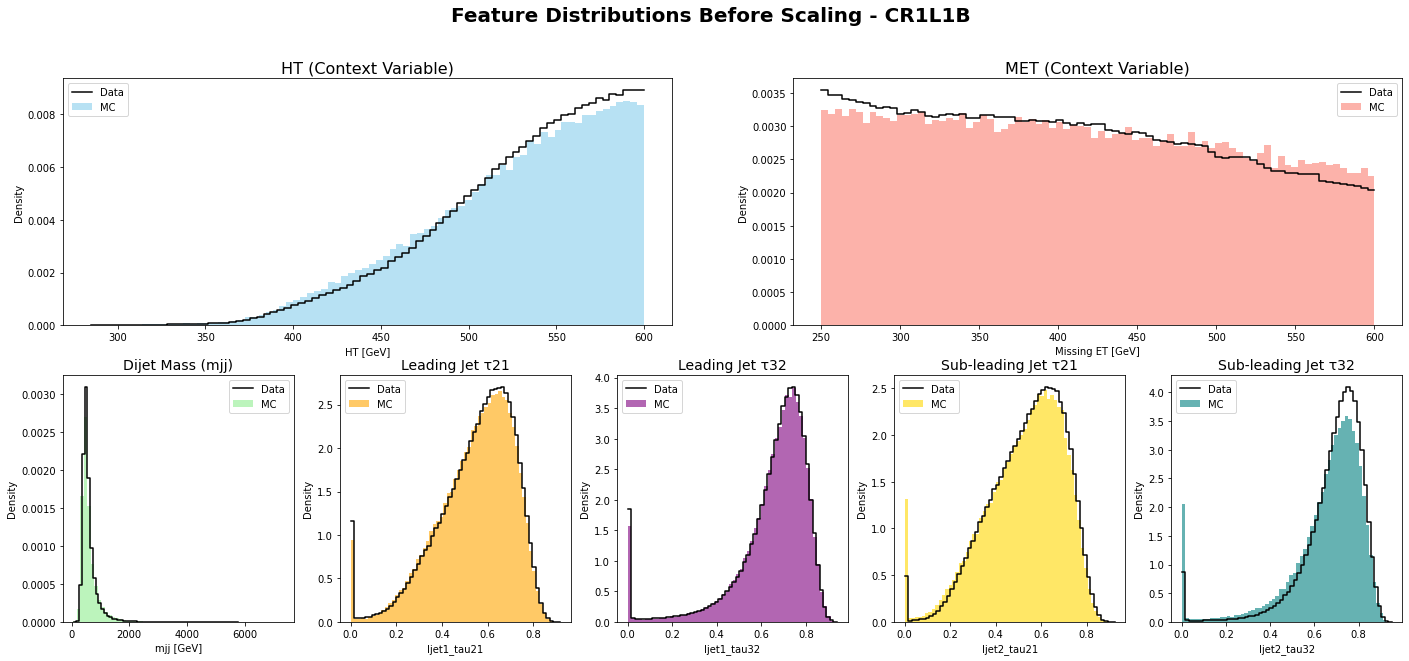

/tmp/ipykernel_173854/2070168937.py:57: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


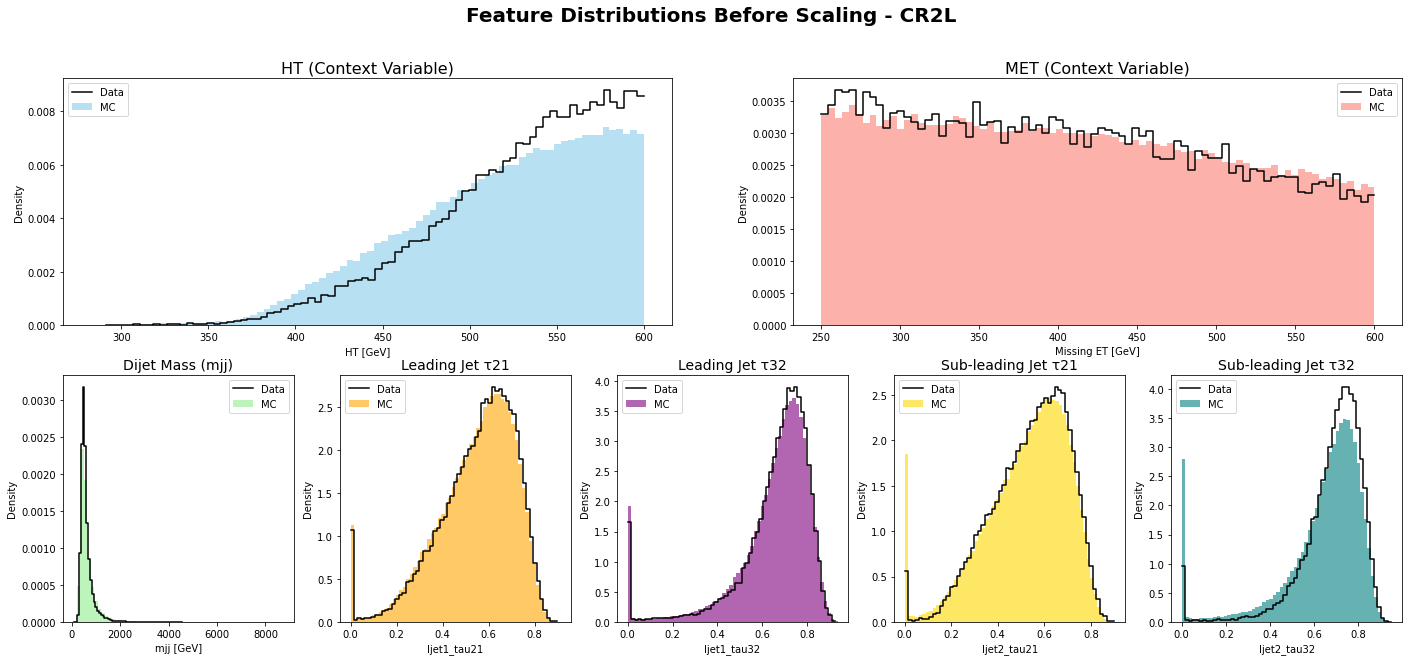

/tmp/ipykernel_173854/2070168937.py:57: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


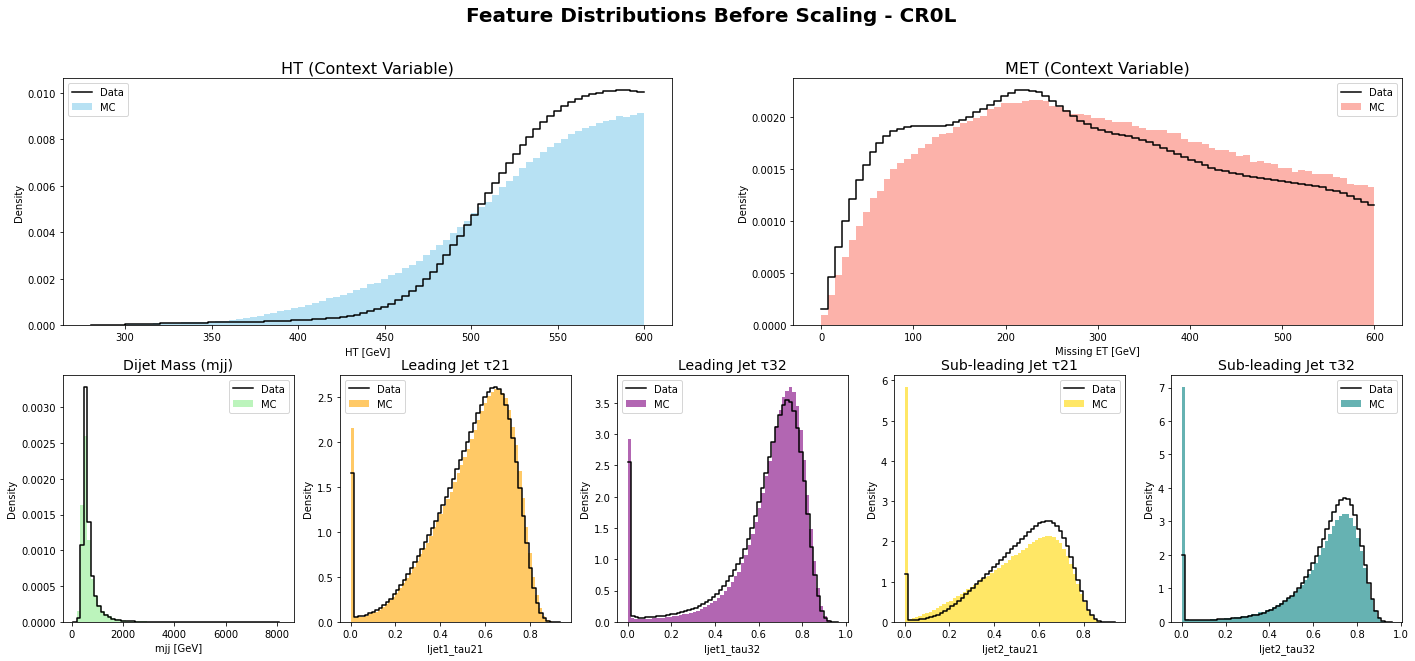

/tmp/ipykernel_173854/2070168937.py:57: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


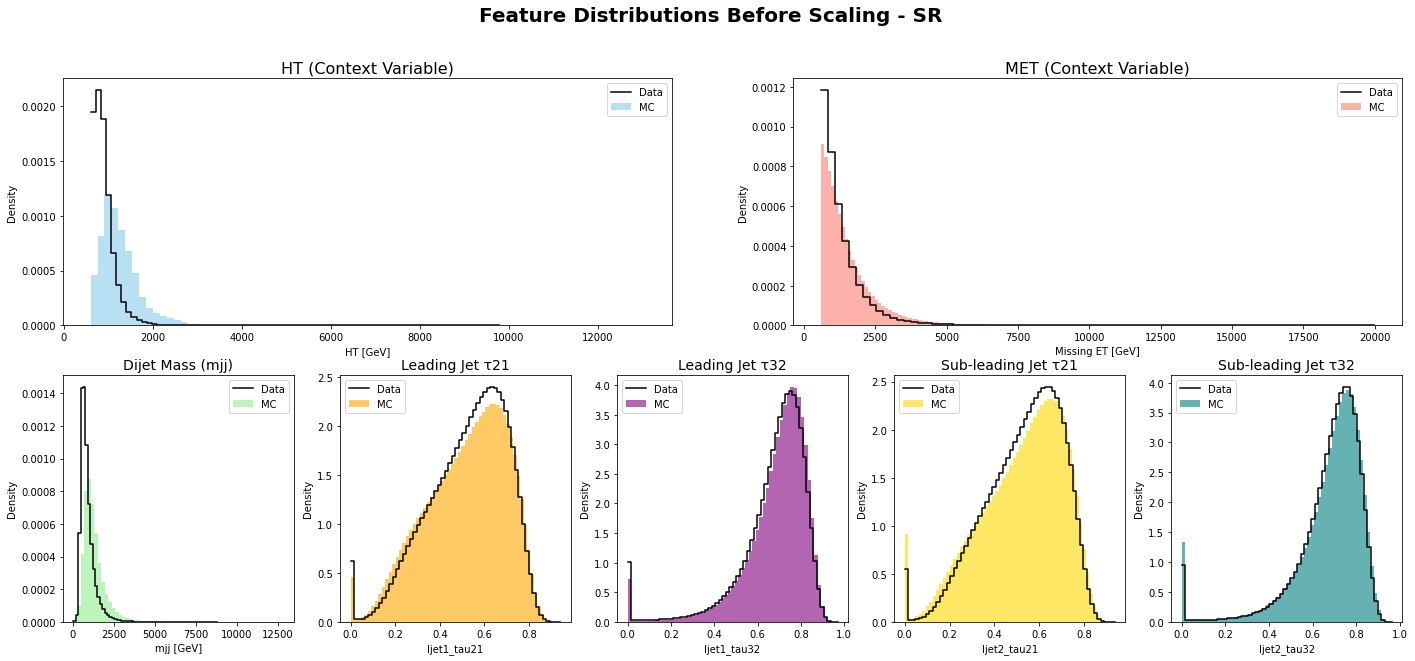

In [32]:
for df_mc, df_data, name in zip(
    [MC_CR1L, MC_CR1L1B, MC_CR2L, MC_CR0L, MC_SR_clean], 
    [DATA_CR1L, DATA_CR1L1B, DATA_CR2L, DATA_CR0L, DATA_SR_clean], 
    names
):
    plot_unscaled_features(df_mc, df_data, title=f"Feature Distributions Before Scaling - {name}")